<a href="https://colab.research.google.com/github/alejitovm97-byte/Alejo-Varelas-projects/blob/main/Macro_driven_ETF_Funds.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Block 1 — Macro Cycle Detection

We identify the current phase of the economic cycle using the Merrill Lynch
Investment Clock framework. Four macro variables sourced from FRED (Industrial
Production, Yield Curve, CPI, PPI) are combined into two composite scores —
Growth and Inflation — to classify the economy into one of four phases and
determine the optimal asset class for the period.

**Analysis date: January 2024**

In [1]:
!pip install pandas numpy matplotlib yfinance requests -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import requests
import warnings
warnings.filterwarnings("ignore")

In [2]:
FRED_BASE = "https://fred.stlouisfed.org/graph/fredgraph.csv?id="

def fetch_fred(series_id, transform="level"):
    """
    Descarga una serie de FRED y la devuelve como pd.Series mensual.

    transform:
        'level' → valores crudos
        'yoy'   → variación % anual (año contra año)
    """
    url = f"{FRED_BASE}{series_id}"
    df  = pd.read_csv(url, index_col=0, parse_dates=True, na_values=".")
    s   = df.iloc[:, 0].dropna()
    s   = s.resample("ME").last().dropna()

    if transform == "yoy":
        s = s.pct_change(12) * 100   # variación vs mismo mes del año anterior

    return s

In [3]:
# Fijamos la fecha de análisis — toda la estrategia se construye con datos hasta enero 2024

pmi         = fetch_fred("BSCICP03USM665S")   # OECD Business Confidence Manufacturing US
yield_curve = fetch_fred("T10Y2Y")
cpi_yoy     = fetch_fred("CPIAUCSL", transform="yoy")
ppi_yoy     = fetch_fred("PPIACO",   transform="yoy")

ANALYSIS_DATE = "2024-01-31"

pmi_t         = pmi[:ANALYSIS_DATE]
yield_curve_t = yield_curve[:ANALYSIS_DATE]
cpi_yoy_t     = cpi_yoy[:ANALYSIS_DATE]
ppi_yoy_t     = ppi_yoy[:ANALYSIS_DATE]

print(f"Fecha de análisis : {ANALYSIS_DATE}")
print(f"PMI         → último valor: {pmi_t.iloc[-1]:.1f}  ({pmi_t.index[-1].strftime('%b %Y')})")
print(f"Yield Curve → último valor: {yield_curve_t.iloc[-1]:.2f}%  ({yield_curve_t.index[-1].strftime('%b %Y')})")
print(f"CPI YoY     → último valor: {cpi_yoy_t.iloc[-1]:.2f}%  ({cpi_yoy_t.index[-1].strftime('%b %Y')})")
print(f"PPI YoY     → último valor: {ppi_yoy_t.iloc[-1]:.2f}%  ({ppi_yoy_t.index[-1].strftime('%b %Y')})")

Fecha de análisis : 2024-01-31
PMI         → último valor: 99.0  (Jan 2024)
Yield Curve → último valor: -0.28%  (Jan 2024)
CPI YoY     → último valor: 3.09%  (Jan 2024)
PPI YoY     → último valor: -3.43%  (Jan 2024)


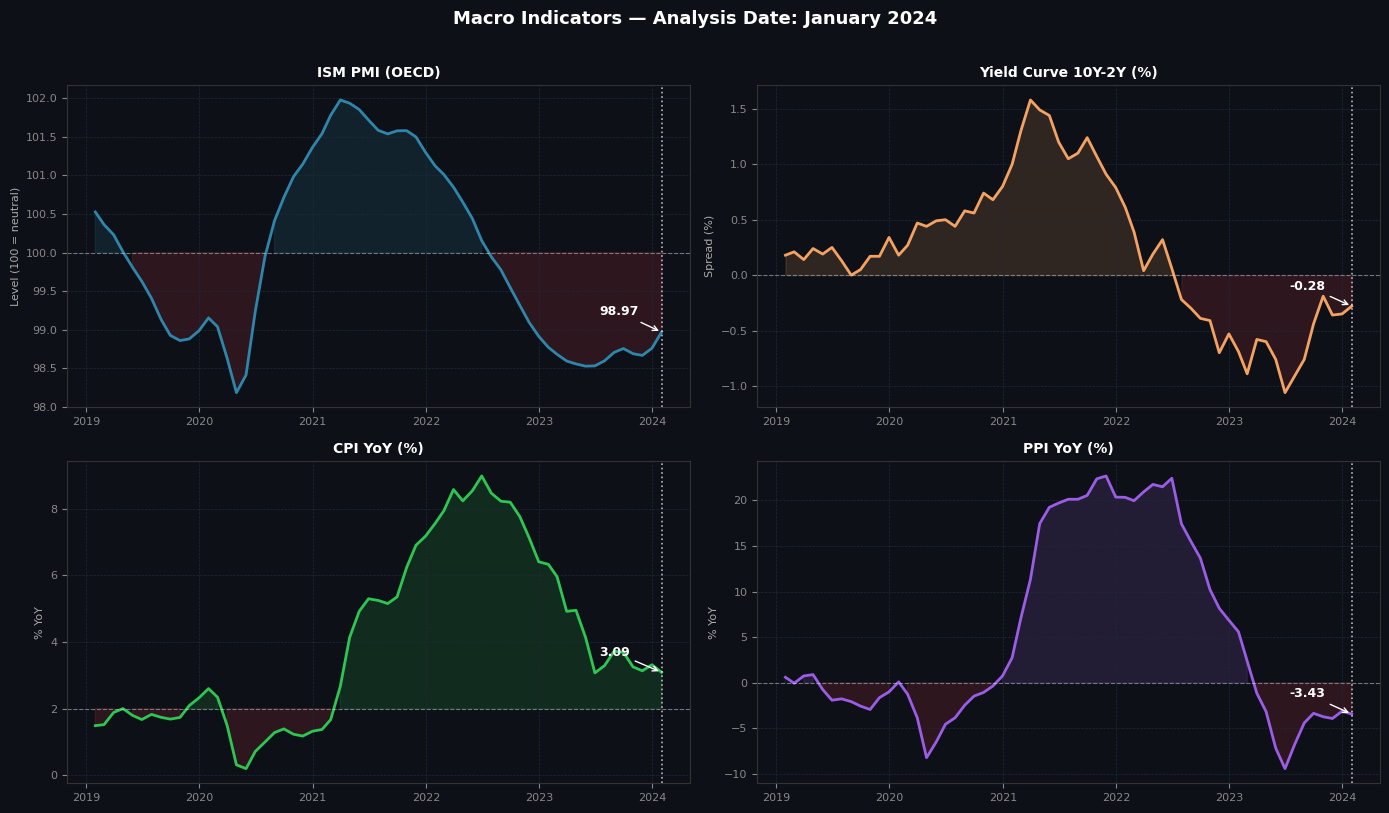

In [4]:
# Graficamos los últimos 5 años hasta Enero 2024 para ver la tendencia de cada serie

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
fig.patch.set_facecolor("#0D1117")
fig.suptitle("Macro Indicators — Analysis Date: January 2024",
             fontsize=13, fontweight="bold", color="white", y=1.01)

# Recortamos a los últimos 5 años para ver el ciclo completo
start_plot = "2019-01-01"

series_config = [
    (pmi_t[start_plot:],         axes[0,0], "ISM PMI (OECD)",         "#2E86AB", 100,   "Level (100 = neutral)"),
    (yield_curve_t[start_plot:], axes[0,1], "Yield Curve 10Y-2Y (%)", "#F4A261",   0,   "Spread (%)"),
    (cpi_yoy_t[start_plot:],     axes[1,0], "CPI YoY (%)",            "#2DC653",   2,   "% YoY"),
    (ppi_yoy_t[start_plot:],     axes[1,1], "PPI YoY (%)",            "#9B5DE5",   0,   "% YoY"),
]

for series, ax, title, color, threshold, ylabel in series_config:
    ax.set_facecolor("#0D1117")

    # Serie principal
    ax.plot(series.index, series.values, color=color, lw=2, label=title)

    # Área bajo/sobre la línea de umbral
    ax.fill_between(series.index, threshold, series.values,
                    where=series.values >= threshold,
                    alpha=0.15, color=color)
    ax.fill_between(series.index, threshold, series.values,
                    where=series.values < threshold,
                    alpha=0.15, color="#E63946")

    # Línea de umbral
    ax.axhline(threshold, color="white", lw=0.8, ls="--", alpha=0.4)

    # Línea vertical en Enero 2024
    ax.axvline(pd.to_datetime(ANALYSIS_DATE), color="white",
               lw=1.2, ls=":", alpha=0.7, label="Analysis date")

    # Anotación del valor en Enero 2024
    ax.annotate(f"{series.iloc[-1]:.2f}",
                xy=(series.index[-1], series.iloc[-1]),
                xytext=(-45, 12), textcoords="offset points",
                color="white", fontsize=9, fontweight="bold",
                arrowprops=dict(arrowstyle="->", color="white", lw=1))

    # Formato
    ax.set_title(title, fontsize=10, fontweight="bold", color="white")
    ax.set_ylabel(ylabel, color="#AAAAAA", fontsize=8)
    ax.tick_params(colors="#888888", labelsize=8)
    ax.grid(True, color="#1E2A3A", lw=0.5, ls="--")
    for spine in ax.spines.values():
        spine.set_color("#333333")

plt.tight_layout()
plt.show()

In [5]:
# Tendencia: variación de los últimos 3 meses
def tendencia_3m(series):
    """
    Calcula el cambio de los últimos 3 meses.
    Positivo = subiendo, Negativo = bajando.
    """
    if len(series) < 4:
        return None
    return series.iloc[-1] - series.iloc[-4]   # valor hoy - valor hace 3 meses

pmi_tend         = tendencia_3m(pmi_t)
yield_curve_tend = tendencia_3m(yield_curve_t)
cpi_tend         = tendencia_3m(cpi_yoy_t)
ppi_tend         = tendencia_3m(ppi_yoy_t)

print("TENDENCIA ÚLTIMOS 3 MESES (Enero 2024)")
print("─" * 45)
print(f"PMI         : {pmi_tend:+.2f}  →  {'↑ Subiendo' if pmi_tend > 0 else '↓ Bajando'}")
print(f"Yield Curve : {yield_curve_tend:+.2f}%  →  {'↑ Subiendo' if yield_curve_tend > 0 else '↓ Bajando'}")
print(f"CPI YoY     : {cpi_tend:+.2f}%  →  {'↑ Subiendo' if cpi_tend > 0 else '↓ Bajando'}")
print(f"PPI YoY     : {ppi_tend:+.2f}%  →  {'↑ Subiendo' if ppi_tend > 0 else '↓ Bajando'}")

TENDENCIA ÚLTIMOS 3 MESES (Enero 2024)
─────────────────────────────────────────────
PMI         : +0.28  →  ↑ Subiendo
Yield Curve : -0.09%  →  ↓ Bajando
CPI YoY     : -0.16%  →  ↓ Bajando
PPI YoY     : +0.30%  →  ↑ Subiendo


In [6]:
def score_indicador(nivel, umbral, tendencia, nombre):
    """
    Produce un score entre -1 y +1 para un indicador.

    Lógica:
        señal_nivel    : +1 si nivel > umbral, -1 si nivel < umbral
        señal_tendencia: +1 si tendencia > 0,  -1 si tendencia < 0

        score = 0.40 × señal_nivel + 0.60 × señal_tendencia

    Parámetros
    ----------
    nivel     : valor actual del indicador
    umbral    : referencia de expansión/contracción (ej: 100 para PMI, 0 para Yield Curve)
    tendencia : cambio 3M (positivo = subiendo)
    nombre    : string para el print
    """
    señal_nivel     = 1 if nivel > umbral else -1
    señal_tendencia = 1 if tendencia > 0  else -1

    score = 0.40 * señal_nivel + 0.60 * señal_tendencia

    print(f"{nombre:<18} | nivel: {nivel:>7.2f} (umbral {umbral}) "
          f"| tend: {tendencia:>+6.2f} "
          f"| score: {score:>+.2f}")

    return score

print("SCORING DE INDICADORES — Enero 2024")
print("─" * 65)

score_pmi    = score_indicador(pmi_t.iloc[-1],         100,  pmi_tend,         "PMI (OECD)")
score_yc     = score_indicador(yield_curve_t.iloc[-1],   0,  yield_curve_tend, "Yield Curve")
score_cpi    = score_indicador(cpi_yoy_t.iloc[-1],       2,  cpi_tend,         "CPI YoY")
score_ppi    = score_indicador(ppi_yoy_t.iloc[-1],       0,  ppi_tend,         "PPI YoY")

SCORING DE INDICADORES — Enero 2024
─────────────────────────────────────────────────────────────────
PMI (OECD)         | nivel:   98.97 (umbral 100) | tend:  +0.28 | score: +0.20
Yield Curve        | nivel:   -0.28 (umbral 0) | tend:  -0.09 | score: -1.00
CPI YoY            | nivel:    3.09 (umbral 2) | tend:  -0.16 | score: -0.20
PPI YoY            | nivel:   -3.43 (umbral 0) | tend:  +0.30 | score: +0.20


In [7]:
# Vector Growth
# PMI pesa más porque es el indicador central del ciclo
# Yield Curve confirma desde el mercado financiero

w_pmi = 0.70
w_yc  = 0.30

growth_score = w_pmi * score_pmi + w_yc * score_yc

# Vector Inflación
# CPI es el dato oficial, PPI es el leading indicator
# Le damos más peso al CPI pero PPI influye como adelantado

w_cpi = 0.60
w_ppi = 0.40

inflation_score = w_cpi * score_cpi + w_ppi * score_ppi

print("VECTORES MACRO — Enero 2024")
print("─" * 45)
print(f"Growth score    : {growth_score:+.3f}")
print(f"Inflation score : {inflation_score:+.3f}")
print()

# Determinación del cuadrante
if growth_score >= 0 and inflation_score < 0:
    phase = "I"
    label = "Recovery"
    asset = "Stocks — Cyclical Growth"
elif growth_score >= 0 and inflation_score >= 0:
    phase = "II"
    label = "Overheating"
    asset = "Commodities — Cyclical Value"
elif growth_score < 0 and inflation_score >= 0:
    phase = "III"
    label = "Hard Landing"
    asset = "Money Market — Defensive"
else:
    phase = "IV"
    label = "Soft Landing"
    asset = "Bonds — Defensive Growth"

print(f"FASE DETECTADA  : Phase {phase} — {label}")
print(f"ACTIVO FAVORITO : {asset}")

VECTORES MACRO — Enero 2024
─────────────────────────────────────────────
Growth score    : -0.160
Inflation score : -0.040

FASE DETECTADA  : Phase IV — Soft Landing
ACTIVO FAVORITO : Bonds — Defensive Growth


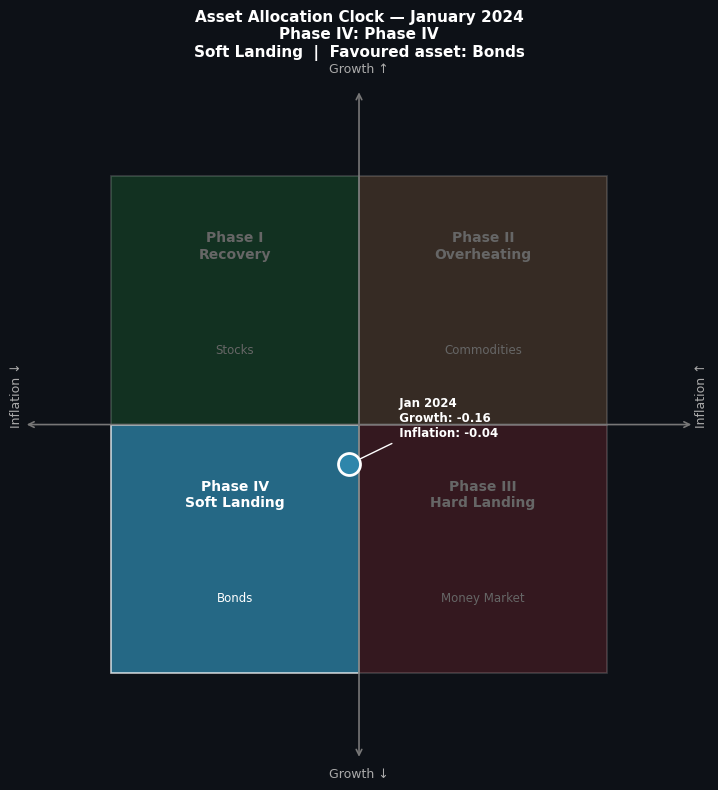

In [8]:
fig, ax = plt.subplots(figsize=(8, 8))
fig.patch.set_facecolor("#0D1117")
ax.set_facecolor("#0D1117")
ax.set_xlim(-1.4, 1.4)
ax.set_ylim(-1.4, 1.4)
ax.set_aspect("equal")
ax.axis("off")

# ── Colores por fase ──────────────────────────────────────────────────────────
phase_colors = {
    "I"  : "#2DC653",   # verde   — Recovery
    "II" : "#F4A261",   # naranja — Overheating
    "III": "#E63946",   # rojo    — Hard Landing
    "IV" : "#2E86AB",   # azul    — Soft Landing
}

# ── Cuadrantes ────────────────────────────────────────────────────────────────
#   Phase I   → Growth ↑, Inflation ↓  → cuadrante superior izquierdo  (-x, +y)
#   Phase II  → Growth ↑, Inflation ↑  → cuadrante superior derecho    (+x, +y)
#   Phase III → Growth ↓, Inflation ↑  → cuadrante inferior derecho    (+x, -y)
#   Phase IV  → Growth ↓, Inflation ↓  → cuadrante inferior izquierdo  (-x, -y)
#
# Eje X = Inflación (izquierda = bajando, derecha = subiendo)
# Eje Y = Growth    (abajo = bajando, arriba = subiendo)

quad_defs = [
    ("I",   -1,  0, "Phase I\nRecovery",      "Stocks"),
    ("II",   0,  0, "Phase II\nOverheating",   "Commodities"),
    ("III",  0, -1, "Phase III\nHard Landing", "Money Market"),
    ("IV",  -1, -1, "Phase IV\nSoft Landing",  "Bonds"),
]

for ph, x0, y0, label, asset in quad_defs:
    alpha = 0.75 if ph == phase else 0.18
    rect  = plt.Rectangle((x0, y0), 1, 1,
                           facecolor=phase_colors[ph],
                           alpha=alpha,
                           edgecolor="white", linewidth=1.2)
    ax.add_patch(rect)

    color_txt = "white" if ph == phase else "#666666"
    ax.text(x0 + 0.5, y0 + 0.72, label,
            ha="center", va="center",
            fontsize=10, fontweight="bold", color=color_txt)
    ax.text(x0 + 0.5, y0 + 0.30, asset,
            ha="center", va="center",
            fontsize=8.5, color=color_txt)

# ── Ejes y etiquetas ──────────────────────────────────────────────────────────
ax.annotate("", xy=(-1.35, 0), xytext=(1.35, 0),
            arrowprops=dict(arrowstyle="<->", color="#777777", lw=1.2))
ax.annotate("", xy=(0, 1.35), xytext=(0, -1.35),
            arrowprops=dict(arrowstyle="<->", color="#777777", lw=1.2))

ax.text( 0,     1.42, "Growth ↑",     ha="center", fontsize=9, color="#AAAAAA")
ax.text( 0,    -1.42, "Growth ↓",     ha="center", fontsize=9, color="#AAAAAA")
ax.text(-1.38,  0,    "Inflation ↓",  ha="center", fontsize=9, color="#AAAAAA", rotation=90)
ax.text( 1.38,  0,    "Inflation ↑",  ha="center", fontsize=9, color="#AAAAAA", rotation=90)

# ── Punto actual ──────────────────────────────────────────────────────────────
# Eje X = inflation_score, Eje Y = growth_score
ax.scatter(inflation_score, growth_score,
           color=phase_colors[phase], s=250, zorder=10,
           edgecolors="white", linewidths=2)

ax.annotate(f"  Jan 2024\n  Growth: {growth_score:+.2f}\n  Inflation: {inflation_score:+.2f}",
            xy=(inflation_score, growth_score),
            xytext=(30, 20), textcoords="offset points",
            color="white", fontsize=8.5, fontweight="bold",
            arrowprops=dict(arrowstyle="->", color="white", lw=1))

# ── Título ────────────────────────────────────────────────────────────────────
ax.set_title(f"Asset Allocation Clock — January 2024\n"
             f"Phase {phase}: {label}  |  Favoured asset: {asset}",
             fontsize=11, fontweight="bold", color="white", pad=15)

plt.tight_layout()
plt.show()

In [9]:
# ── Intensidad de la señal ────────────────────────────────────────────────────
# Distancia euclidiana desde el origen — qué tan lejos del centro estamos
# Normalizada: máxima distancia posible es √2 (cuando ambos scores = ±1)

distancia = np.sqrt(growth_score**2 + inflation_score**2)
distancia_norm = distancia / np.sqrt(2)   # entre 0 y 1

# ── Split Core / Satellite según intensidad ───────────────────────────────────
if distancia_norm >= 0.55:
    core_pct = 0.80
    sat_pct  = 0.20
    conviccion = "ALTA"
elif distancia_norm >= 0.30:
    core_pct = 0.70
    sat_pct  = 0.30
    conviccion = "MEDIA"
else:
    core_pct = 0.60
    sat_pct  = 0.40
    conviccion = "BAJA — señal de transición"

print("INTENSIDAD DE SEÑAL — Enero 2024")
print("─" * 45)
print(f"Growth score    : {growth_score:+.3f}")
print(f"Inflation score : {inflation_score:+.3f}")
print(f"Distancia centro: {distancia:.3f}  ({distancia_norm:.1%} del máximo)")
print(f"Convicción      : {conviccion}")

INTENSIDAD DE SEÑAL — Enero 2024
─────────────────────────────────────────────
Growth score    : -0.160
Inflation score : -0.040
Distancia centro: 0.165  (11.7% del máximo)
Convicción      : BAJA — señal de transición


## Block 2 — Fund Universe & Instrument Selection

We screen a universe of 761 instruments (327 ETFs + 434 Mutual Funds) sourced
from Morningstar across 13 categories. Each instrument is scored using a
weighted quintile ranking system based on Sharpe ratio, 3Y return, alpha,
momentum, and volatility. Only Q1 instruments (top 20% within each category)
are eligible for portfolio inclusion.

The macro phase detected in Block 1 determines which asset classes are
activated and their role (Core vs Transition).

In [10]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [11]:
# Descarga manual de los datos de ETFs/Fondos desde Morningstar y subida a python

BASE_PATH = "/content/drive/MyDrive/TFM/data"
ETF_PATH  = BASE_PATH + "/etfs"
FUND_PATH = BASE_PATH + "/funds"

ETF_FILES = {
    "US Large-Cap Blend Equity" : {
        "perf" : "US large-cap blend equity perf.xlsx",
        "risk" : "US large-cap Blend Equity risk.xlsx",
    },
    "Europe Large-Cap Blend Equity" : {
        "perf" : "Euro large-cap blend perf.xlsx",
        "risk" : "Euro large-cap blend risk.xlsx",
    },
    "Emerging Markets Equity" : {
        "perf" : "Emerging markets equity.xlsx",
        "risk" : "Emerging markets equity risk.xlsx",
    },
    "Global Large-Cap Blend Equity" : {
        "perf" : "Global larg cap blend equity.xlsx",
        "risk" : "Global larg cap blend risk.xlsx",
    },
    "USD Bond Long Term" : {
        "perf" : "USD GOV BOND perf.xlsx",
        "risk" : "USD GOV BOND risk.xlsx",
    },
    "USD Bond Short Term" : {
        "perf" : "USD GOV BOND SHORT perf.xlsx",
        "risk" : "USD GOV BOND SHORT risk.xlsx",
    },
    "EUR Bond" : {
        "perf" : "Euro bond perf.xlsx",
        "risk" : "Euro bond risk.xlsx",
    },
    "Property Indirect Global" : {
        "perf" : "property ind global perf.xlsx",
        "risk" : "Property ind global risk.xlsx",
    },
    "Money Market" : {
        "perf" : "mONEY MARKET perf.xlsx",
        "risk" : "MONEY MARKET risk.xlsx",
    },
    "Commodities Broad Basket" : {
        "perf" : "Commodities broad basket perf.xlsx",
        "risk" : "Commodities broad basket risk.xlsx",
    },
    "Sector Equity Technology" : {
        "perf" : "Sector tecnology perf.xlsx",
        "risk" : "Sector tecnology risk.xlsx",
    },
    "Sector Equity Ecology" : {
        "perf" : "Sector ecology perf.xlsx",
        "risk" : "Sector ecology risk.xlsx",
    },
    "Alternative Other" : {
        "perf" : "Alternative other perf.xlsx",
        "risk" : "Alternative other risk.xlsx",
    },
}

FUND_FILES = {
    "US Large-Cap Blend Equity" : {
        "perf" : "F US LARGE CAP BLEND EQUITY.xlsx",
        "risk" : "F US LARGE CAP BLEND EQUITY RISK.xlsx",
        "fee"  : "F US LARGE CAP BLEND FEE.xlsx",
    },
    "Europe Large-Cap Blend Equity" : {
        "perf" : "F Europe large cap blend perf.xlsx",
        "risk" : "F Europe larg cap blend risk.xlsx",
        "fee"  : "F EUROPE LARG CAP BLEND FEE.xlsx",
    },
    "Emerging Markets Equity" : {
        "perf" : "F Emerging mark larg cap blend perf.xlsx",
        "risk" : "F Emerging mark larg cap blend risk.xlsx",
        "fee"  : "F Emerging market larg cap blend fee.xlsx",
    },
    "Global Large-Cap Blend Equity" : {
        "perf" : "F Global larg cap blend perf.xlsx",
        "risk" : "F Global larg cap blend risk.xlsx",
        "fee"  : "F Global larg cap blend fee.xlsx",
    },
    "USD Bond Long Term" : {
        "perf" : "F US BOND PERF.xlsx",
        "risk" : "F US BOND RISK.xlsx",
        "fee"  : "F US BOND FEE.xlsx",
    },
    "USD Bond Short Term" : {
        "perf" : "F US BOND SHORT PERF.xlsx",
        "risk" : "F US BOND SHORT RISK.xlsx",
        "fee"  : "F US BOND SHORT FEE.xlsx",
    },
    "EUR Bond" : {
        "perf" : "F EURO BOND PERF.xlsx",
        "risk" : "F EURO BOND RISK.xlsx",
        "fee"  : "F EURO BOND FEE.xlsx",
    },
    "Property Indirect Global" : {
        "perf" : "F PROPERTY INDIRECT GLOBAL PERF .xlsx",
        "risk" : "F PROPERTY INDIRECT GLOBAL RISK.xlsx",
        "fee"  : "F PROPEERTY INDIRECT GLOBAL FEE.xlsx",
    },
    "Sector Equity Technology" : {
        "perf" : "F TECHNOLOGY PERF.xlsx",
        "risk" : "F TECH RISK.xlsx",
        "fee"  : "F TECH FEE.xlsx",
    },
    "Sector Equity Ecology" : {
        "perf" : "F ECOLOGY PERF.xlsx",
        "risk" : "F ECOLOGY RISK.xlsx",
        "fee"  : "F ECOLOGY FEE.xlsx",
    },
}

# Categorías SOLO en ETFs (no tienen fondos):
SOLO_ETF = ["Money Market", "Commodities Broad Basket", "Alternative Other"]

print(f"   ETF categorías  : {len(ETF_FILES)}")
print(f"   Fund categorías : {len(FUND_FILES)}")

   ETF categorías  : 13
   Fund categorías : 10


In [12]:
import pandas as pd
import os

def cargar_categoria_etf(categoria, archivos):
    """
    Carga y une perf + risk de un ETF.
    Retorna DataFrame con ambas tablas unidas por Name + ISIN.
    """
    perf_path = os.path.join(ETF_PATH, archivos["perf"])
    risk_path = os.path.join(ETF_PATH, archivos["risk"])

    # Verificar existencia
    for nombre, path in [("perf", perf_path), ("risk", risk_path)]:
        if not os.path.exists(path):
            print(f"  ❌  No encontrado [{categoria}] {nombre}: {path}")
            return pd.DataFrame()

    perf = pd.read_excel(perf_path)
    risk = pd.read_excel(risk_path)

    perf.columns = perf.columns.str.strip()
    risk.columns = risk.columns.str.strip()

    # Unir por Name + ISIN
    df = pd.merge(perf, risk, on=["Name", "ISIN"], how="inner")
    df["Category"] = categoria
    df["Type"]     = "ETF"

    print(f"  ✅  ETF  {categoria:<35} → {len(df):>3} instrumentos")
    return df


def cargar_categoria_fund(categoria, archivos):
    """
    Carga y une perf + risk + fee de un fondo.
    Retorna DataFrame con las tres tablas unidas por Name + ISIN.
    """
    perf_path = os.path.join(FUND_PATH, archivos["perf"])
    risk_path = os.path.join(FUND_PATH, archivos["risk"])
    fee_path  = os.path.join(FUND_PATH, archivos["fee"])

    # Verificar existencia
    for nombre, path in [("perf", perf_path), ("risk", risk_path), ("fee", fee_path)]:
        if not os.path.exists(path):
            print(f"  ❌  No encontrado [{categoria}] {nombre}: {path}")
            return pd.DataFrame()

    perf = pd.read_excel(perf_path)
    risk = pd.read_excel(risk_path)
    fee  = pd.read_excel(fee_path)

    perf.columns = perf.columns.str.strip()
    risk.columns = risk.columns.str.strip()
    fee.columns  = fee.columns.str.strip()

    # Unir por Name + ISIN
    df = pd.merge(perf, risk, on=["Name", "ISIN"], how="inner")
    df = pd.merge(df,   fee,  on=["Name", "ISIN"], how="left")
    df["Category"] = categoria
    df["Type"]     = "Fund"

    print(f"  ✅  Fund {categoria:<35} → {len(df):>3} instrumentos")
    return df

print("✅ Funciones de carga definidas")

✅ Funciones de carga definidas


In [13]:
import os

# ── Editá esta ruta con la tuya exacta ───────────────────────────────────────
BASE_PATH = "/content/drive/MyDrive/TFM/data"
ETF_PATH  = BASE_PATH + "/etfs"
FUND_PATH = BASE_PATH + "/funds"

# ── Verificar que las carpetas existen ────────────────────────────────────────
print("¿Existe BASE_PATH?", os.path.exists(BASE_PATH))
print("¿Existe ETF_PATH? ", os.path.exists(ETF_PATH))
print("¿Existe FUND_PATH?", os.path.exists(FUND_PATH))

# ── Si existen, listar los archivos ──────────────────────────────────────────
if os.path.exists(ETF_PATH):
    print(f"\nArchivos en etfs/ ({len(os.listdir(ETF_PATH))}):")
    for f in sorted(os.listdir(ETF_PATH)):
        print(f"  '{f}'")
else:
    print("\n❌ ETF_PATH no encontrado — listando MyDrive para encontrar la ruta:")
    for f in sorted(os.listdir("/content/drive/MyDrive")):
        print(f"  '{f}'")

¿Existe BASE_PATH? True
¿Existe ETF_PATH?  True
¿Existe FUND_PATH? True

Archivos en etfs/ (26):
  'Alternative other perf.xlsx'
  'Alternative other risk.xlsx'
  'Commodities broad basket perf.xlsx'
  'Commodities broad basket risk.xlsx'
  'Emerging markets equity risk.xlsx'
  'Emerging markets equity.xlsx'
  'Euro bond perf.xlsx'
  'Euro bond risk.xlsx'
  'Euro large-cap blend perf.xlsx'
  'Euro large-cap blend risk.xlsx'
  'Global larg cap blend equity.xlsx'
  'Global larg cap blend risk.xlsx'
  'MONEY MARKET risk.xlsx'
  'Property ind global risk.xlsx'
  'Sector ecology perf.xlsx'
  'Sector ecology risk.xlsx'
  'Sector tecnology perf.xlsx'
  'Sector tecnology risk.xlsx'
  'US large-cap Blend Equity risk.xlsx'
  'US large-cap blend equity perf.xlsx'
  'USD GOV BOND SHORT perf.xlsx'
  'USD GOV BOND SHORT risk.xlsx'
  'USD GOV BOND perf.xlsx'
  'USD GOV BOND risk.xlsx'
  'mONEY MARKET perf.xlsx'
  'property ind global perf.xlsx'


In [14]:
frames = []

print("CARGANDO ETFs...")
print("─" * 55)
for categoria, archivos in ETF_FILES.items():
    df = cargar_categoria_etf(categoria, archivos)
    if not df.empty:
        frames.append(df)

print("\nCARGANDO FONDOS...")
print("─" * 55)
for categoria, archivos in FUND_FILES.items():
    df = cargar_categoria_fund(categoria, archivos)
    if not df.empty:
        frames.append(df)

# Consolidar
universo = pd.concat(frames, ignore_index=True)

print(f"\n{'─' * 55}")
print(f"UNIVERSO TOTAL   : {len(universo)} instrumentos")
print(f"  ETFs           : {(universo['Type'] == 'ETF').sum()}")
print(f"  Fondos         : {(universo['Type'] == 'Fund').sum()}")
print(f"  Categorías     : {universo['Category'].nunique()}")
print(f"\nInstrumentos por categoría:")
print(universo.groupby(["Category","Type"]).size().to_string())

CARGANDO ETFs...
───────────────────────────────────────────────────────
  ✅  ETF  US Large-Cap Blend Equity           →  69 instrumentos
  ✅  ETF  Europe Large-Cap Blend Equity       →   7 instrumentos
  ✅  ETF  Emerging Markets Equity             →  49 instrumentos
  ✅  ETF  Global Large-Cap Blend Equity       →  72 instrumentos
  ✅  ETF  USD Bond Long Term                  →  21 instrumentos
  ✅  ETF  USD Bond Short Term                 →   4 instrumentos
  ✅  ETF  EUR Bond                            →   2 instrumentos
  ✅  ETF  Property Indirect Global            →   5 instrumentos
  ✅  ETF  Money Market                        →   5 instrumentos
  ✅  ETF  Commodities Broad Basket            →  15 instrumentos
  ✅  ETF  Sector Equity Technology            →  71 instrumentos
  ✅  ETF  Sector Equity Ecology               →   5 instrumentos
  ✅  ETF  Alternative Other                   →   2 instrumentos

CARGANDO FONDOS...
───────────────────────────────────────────────────────
  ✅  F

In [15]:
# Antes de limpiar, inspeccionamos qué columnas llegaron
print("COLUMNAS DEL UNIVERSO CONSOLIDADO")
print("─" * 55)
for col in universo.columns:
    non_null = universo[col].notna().sum()
    pct      = non_null / len(universo) * 100
    print(f"  {col:<45} {non_null:>4}/{len(universo)}  ({pct:>5.1f}% completo)")

COLUMNAS DEL UNIVERSO CONSOLIDADO
───────────────────────────────────────────────────────
  Name                                           761/761  (100.0% completo)
  ISIN                                           761/761  (100.0% completo)
  Total Return (%) (1 Day)                       761/761  (100.0% completo)
  Total Return (%) (1 Week)                      761/761  (100.0% completo)
  Total Return (%) (1 Month)                     761/761  (100.0% completo)
  Total Return (%) (3 Month)                     761/761  (100.0% completo)
  Total Return (%) (6 Month)                     761/761  (100.0% completo)
  Total Return (%) (YTD)                         761/761  (100.0% completo)
  Total Return (%) (1 Year)                      739/761  ( 97.1% completo)
  Total Return (%) (3 Year)                      684/761  ( 89.9% completo)
  Total Return (%) (5 Year)                      583/761  ( 76.6% completo)
  Total Return (%) (10 Year)                     350/761  ( 46.0% completo

In [16]:
# ── Renombrar columnas a nombres cortos y manejables ─────────────────────────
universo = universo.rename(columns={
    "Total Return (%) (1 Year)"            : "Return_1Y",
    "Total Return (%) (3 Year)"            : "Return_3Y",
    "Total Return (%) (5 Year)"            : "Return_5Y",
    "Total Return (%) (10 Year)"           : "Return_10Y",
    "Total Return (%) (1 Month)"           : "Return_1M",
    "Total Return (%) (3 Month)"           : "Return_3M",
    "Total Return (%) (6 Month)"           : "Return_6M",
    "Alpha (3 Year, Monthly)"              : "Alpha_3Y",
    "Beta (3 Year, Monthly)"               : "Beta_3Y",
    "R-Squared (3 Year, Monthly)"          : "R2_3Y",
    "Standard Deviation (3 Year, Monthly)" : "StdDev_3Y",
    "Sharpe Ratio (3 Year, Monthly)"       : "Sharpe_3Y",
    "KIID Ongoing Charge"                  : "Expense_Ratio",
    "SRRI"                                 : "SRRI",
})

# ── Convertir columnas numéricas (algunos valores vienen como string con −) ───
numeric_cols = [
    "Return_1Y", "Return_3Y", "Return_5Y", "Return_10Y",
    "Return_1M", "Return_3M", "Return_6M",
    "Alpha_3Y", "Beta_3Y", "R2_3Y",
    "StdDev_3Y", "Sharpe_3Y", "Expense_Ratio", "SRRI",
]
for col in numeric_cols:
    if col in universo.columns:
        # Reemplazar el guión largo − (Unicode) por el guión normal -
        universo[col] = (
            universo[col]
            .astype(str)
            .str.replace("−", "-", regex=False)
            .str.replace(",", ".", regex=False)
            .str.strip()
        )
        universo[col] = pd.to_numeric(universo[col], errors="coerce")

# ── Sortino aproximado ────────────────────────────────────────────────────────
universo["Sortino_aprox"] = universo["Sharpe_3Y"] * 1.3

# ── Vista resumen ─────────────────────────────────────────────────────────────
print("COLUMNAS LIMPIAS — MÉTRICAS DE SCORING")
print("─" * 50)
scoring_cols = ["Return_1Y","Return_3Y","Return_5Y",
                "Sharpe_3Y","Sortino_aprox","Alpha_3Y",
                "StdDev_3Y","Expense_Ratio"]
for col in scoring_cols:
    validos = universo[col].notna().sum()
    media   = universo[col].mean()
    print(f"  {col:<20} {validos:>4} válidos | media: {media:>8.2f}")

print(f"\nMuestra de 3 instrumentos:")
print(universo[["Name","Type","Category"] + scoring_cols].head(3).to_string())

COLUMNAS LIMPIAS — MÉTRICAS DE SCORING
──────────────────────────────────────────────────
  Return_1Y             739 válidos | media:    18.96
  Return_3Y             684 válidos | media:    15.14
  Return_5Y             583 válidos | media:     9.45
  Sharpe_3Y             684 válidos | media:     1.00
  Sortino_aprox         684 válidos | media:     1.30
  Alpha_3Y              666 válidos | media:    -0.90
  StdDev_3Y             684 válidos | media:    13.49
  Expense_Ratio         431 válidos | media:     0.92

Muestra de 3 instrumentos:
                                                     Name Type                   Category  Return_1Y  Return_3Y  Return_5Y  Sharpe_3Y  Sortino_aprox  Alpha_3Y  StdDev_3Y  Expense_Ratio
0             Amundi Core S&P 500 Swap UCITS ETF USD Dist  ETF  US Large-Cap Blend Equity      19.88      20.80      14.29       1.36          1.768      0.69      11.49            NaN
1  Fidelity US Equity Research Enhanced UCITS ETF USD Acc  ETF  US Large-Cap Ble

In [17]:
# ── Definimos las métricas mínimas obligatorias para entrar al scoring ────────
# Un instrumento debe tener AL MENOS estas 4 columnas para ser válido

COLS_OBLIGATORIAS = ["Return_1Y", "Return_3Y", "Sharpe_3Y", "StdDev_3Y"]

antes = len(universo)
universo_limpio = universo.dropna(subset=COLS_OBLIGATORIAS).copy()
despues = len(universo_limpio)

print(f"Instrumentos antes  : {antes}")
print(f"Instrumentos después: {despues}")
print(f"Eliminados          : {antes - despues} (datos insuficientes)")
print()
print("Instrumentos válidos por categoría:")
print(universo_limpio.groupby(["Category","Type"]).size().to_string())

Instrumentos antes  : 761
Instrumentos después: 684
Eliminados          : 77 (datos insuficientes)

Instrumentos válidos por categoría:
Category                       Type
Alternative Other              ETF      1
Commodities Broad Basket       ETF     12
EUR Bond                       ETF      1
                               Fund     4
Emerging Markets Equity        ETF     41
                               Fund    58
Europe Large-Cap Blend Equity  ETF      6
                               Fund    72
Global Large-Cap Blend Equity  ETF     48
                               Fund    59
Money Market                   ETF      5
Property Indirect Global       ETF      4
                               Fund    50
Sector Equity Ecology          ETF      4
                               Fund    53
Sector Equity Technology       ETF     58
                               Fund    71
US Large-Cap Blend Equity      ETF     49
                               Fund    60
USD Bond Long Term            

In [18]:
# ── Pesos del scoring ─────────────────────────────────────────────────────────
#
# Lógica de pesos:
#   Sharpe_3Y    → 30% — métrica central, retorno ajustado por riesgo
#   Return_3Y    → 25% — performance del ciclo completo
#   Alpha_3Y     → 20% — valor agregado vs benchmark
#   Return_1Y    → 15% — momentum reciente (más relevante para timing)
#   StdDev_3Y    → 10% — volatilidad (invertido: menor vol = mejor score)
#
# Expense_Ratio NO entra al score principal porque solo cubre fondos (56%)
# → lo usamos como criterio de desempate al final

PESOS = {
    "Sharpe_3Y" : 0.30,
    "Return_3Y" : 0.25,
    "Alpha_3Y"  : 0.20,
    "Return_1Y" : 0.15,
    "StdDev_3Y" : 0.10,
}

def normalizar_minmax(series):
    rng = series.max() - series.min()
    if rng == 0:
        return pd.Series(0.5, index=series.index)
    return (series - series.min()) / rng

def calcular_score_y_quintiles(df_grupo):
    """
    1. Normaliza cada métrica dentro del grupo
    2. Calcula score compuesto
    3. Asigna quintil (Q1 = mejor 20%, Q5 = peor 20%)

    Grupos pequeños (<5): asigna quintil directamente por ranking
    """
    df = df_grupo.copy()

    # ── Score ─────────────────────────────────────────────────────────────────
    for col in PESOS:
        col_norm = col + "_norm"
        vals     = pd.to_numeric(df[col], errors="coerce")

        if vals.notna().sum() < 2:
            df[col_norm] = 0.5
            continue

        norm = normalizar_minmax(vals)
        if col == "StdDev_3Y":
            norm = 1 - norm
        df[col_norm] = norm

    df["Score"] = sum(
        df[col + "_norm"] * peso
        for col, peso in PESOS.items()
    )

    # ── Quintiles ─────────────────────────────────────────────────────────────
    n = len(df)
    if n >= 5:
        # Quintiles estándar — Q1 = top 20%
        df["Quintil"] = pd.qcut(
            df["Score"],
            q=5,
            labels=["Q5","Q4","Q3","Q2","Q1"],  # invertido: mayor score = Q1
            duplicates="drop",
        )
    else:
        # Grupo pequeño: ranking directo
        df["Rank"]    = df["Score"].rank(ascending=False).astype(int)
        df["Quintil"] = df["Rank"].apply(lambda r: f"Q{min(r, 5)}")

    # ── Rank dentro del grupo ─────────────────────────────────────────────────
    df["Rank_grupo"] = df["Score"].rank(ascending=False).astype(int)

    return df.sort_values("Score", ascending=False)

# ── Aplicar por Category + Type ───────────────────────────────────────────────
grupos = []
for (categoria, tipo), grupo in universo_limpio.groupby(["Category","Type"]):
    scored = calcular_score_y_quintiles(grupo)
    grupos.append(scored)

universo_scored = pd.concat(grupos, ignore_index=True)

# ── Resumen por grupo ─────────────────────────────────────────────────────────
print("SCORING + QUINTILES COMPLETADO")
print("─" * 65)
print(f"{'Tipo':<6} {'Categoría':<35} {'Total':>5} {'Q1':>5}")
print("─" * 65)

resumen = (universo_scored
           .groupby(["Category","Type","Quintil"])
           .size()
           .unstack(fill_value=0))

for (cat, tipo), grupo in universo_scored.groupby(["Category","Type"]):
    total = len(grupo)
    q1    = (grupo["Quintil"] == "Q1").sum()
    print(f"  {tipo:<6} {cat:<35} {total:>5} {q1:>5}")

print(f"\n  TOTAL: {len(universo_scored)} instrumentos")
print(f"  Q1 total: {(universo_scored['Quintil'] == 'Q1').sum()} instrumentos")

SCORING + QUINTILES COMPLETADO
─────────────────────────────────────────────────────────────────
Tipo   Categoría                           Total    Q1
─────────────────────────────────────────────────────────────────
  ETF    Alternative Other                       1     1
  ETF    Commodities Broad Basket               12     3
  ETF    EUR Bond                                1     1
  Fund   EUR Bond                                4     1
  ETF    Emerging Markets Equity                41     8
  Fund   Emerging Markets Equity                58    12
  ETF    Europe Large-Cap Blend Equity           6     1
  Fund   Europe Large-Cap Blend Equity          72    15
  ETF    Global Large-Cap Blend Equity          48    10
  Fund   Global Large-Cap Blend Equity          59    12
  ETF    Money Market                            5     1
  ETF    Property Indirect Global                4     1
  Fund   Property Indirect Global               50    10
  ETF    Sector Equity Ecology           

In [19]:
# ── Filtrar solo Q1 ───────────────────────────────────────────────────────────
q1 = universo_scored[universo_scored["Quintil"] == "Q1"].copy()

cols_ver = ["Rank_grupo", "Name", "Type", "Category",
            "Score", "Sharpe_3Y", "Return_3Y", "Alpha_3Y",
            "StdDev_3Y", "Return_1Y"]

# ── Mostrar Q1 por cada grupo separado ───────────────────────────────────────
for (categoria, tipo), grupo in q1.groupby(["Category", "Type"]):
    print(f"\n{'═'*70}")
    print(f"  {tipo} — {categoria}  ({len(grupo)} instrumentos en Q1)")
    print(f"{'─'*70}")
    print(grupo[cols_ver]
          .sort_values("Score", ascending=False)
          .to_string(index=False))

print(f"\n{'═'*70}")
print(f"  TOTAL Q1: {len(q1)} instrumentos")


══════════════════════════════════════════════════════════════════════
  ETF — Alternative Other  (1 instrumentos en Q1)
──────────────────────────────────────────────────────────────────────
 Rank_grupo                                           Name Type          Category  Score  Sharpe_3Y  Return_3Y  Alpha_3Y  StdDev_3Y  Return_1Y
          1 Amundi US Curve steepening 2-10Y UCITS ETF Acc  ETF Alternative Other    0.5      -0.55       2.79       NaN       3.76       1.14

══════════════════════════════════════════════════════════════════════
  ETF — Commodities Broad Basket  (3 instrumentos en Q1)
──────────────────────────────────────────────────────────────────────
 Rank_grupo                                                                                  Name Type                 Category    Score  Sharpe_3Y  Return_3Y  Alpha_3Y  StdDev_3Y  Return_1Y
          1                        WisdomTree Enhanced Commodity ex-Agriculture UCITS ETF USD Acc  ETF Commodities Broad Basket 0.

In [20]:
#Phase I   Recovery     → US Large-Cap, Global Large-Cap, Emerging Markets
#Phase II  Overheating  → Commodities, Europe Large-Cap, Property Global
#Phase III Hard Landing → Money Market, USD Bond Short Term
#Phase IV  Soft Landing → USD Bond Long Term, EUR Bond, Property Global (hedge)

# ── Mapa de fases → categorías relevantes ────────────────────────────────────
FASE_CATEGORIAS = {
    "I"  : [
        "US Large-Cap Blend Equity",
        "Global Large-Cap Blend Equity",
        "Emerging Markets Equity",
        "Europe Large-Cap Blend Equity",
    ],
    "II" : [
        "Commodities Broad Basket",
        "Europe Large-Cap Blend Equity",
        "Property Indirect Global",
        "US Large-Cap Blend Equity",
    ],
    "III": [
        "Money Market",
        "USD Bond Short Term",
        "Alternative Other",
    ],
    "IV" : [
        "USD Bond Long Term",       # core — Phase IV principal
        "EUR Bond",                 # core — diversificación geográfica
        "Money Market",             # hedge — convicción baja
        "USD Bond Short Term",      # hedge — convicción baja
        "Property Indirect Global", # diversificador real assets
    ],
}

# ── Categorías de transición hacia Phase I ────────────────────────────────────
# Convicción BAJA → el ciclo se está moviendo → pequeña exposición anticipatoria
TRANSICION_PHASE_I = [
    "US Large-Cap Blend Equity",
    "Global Large-Cap Blend Equity",
]

# ── Aplicar filtro para Phase IV ──────────────────────────────────────────────
categorias_phase = FASE_CATEGORIAS[phase]
categorias_totales = categorias_phase + TRANSICION_PHASE_I

# Eliminar duplicados manteniendo orden
categorias_totales = list(dict.fromkeys(categorias_totales))

print(f"FILTRO POR FASE — Phase {phase}: {label}")
print(f"Convicción: {conviccion}")
print("─" * 55)
print(f"\nCategorías CORE (Phase {phase}):")
for cat in categorias_phase:
    n = len(q1[q1["Category"] == cat])
    print(f"  ✅  {cat:<35} ({n} instrumentos en Q1)")

print(f"\nCategorías TRANSICIÓN (hacia Phase I):")
for cat in TRANSICION_PHASE_I:
    n = len(q1[q1["Category"] == cat])
    print(f"  🔄  {cat:<35} ({n} instrumentos en Q1)")

# ── Filtrar Q1 solo de categorías relevantes ──────────────────────────────────
q1_fase = q1[q1["Category"].isin(categorias_totales)].copy()

print(f"\n{'─' * 55}")
print(f"Instrumentos Q1 relevantes para Phase {phase}: {len(q1_fase)}")
print(f"\nDesglose:")
for (cat, tipo), grupo in q1_fase.groupby(["Category","Type"]):
    print(f"  {tipo:<6} {cat:<35} → {len(grupo):>2} instrumentos")

FILTRO POR FASE — Phase IV: Phase IV
Soft Landing
Convicción: BAJA — señal de transición
───────────────────────────────────────────────────────

Categorías CORE (Phase IV):
  ✅  USD Bond Long Term                  (5 instrumentos en Q1)
  ✅  EUR Bond                            (2 instrumentos en Q1)
  ✅  Money Market                        (1 instrumentos en Q1)
  ✅  USD Bond Short Term                 (2 instrumentos en Q1)
  ✅  Property Indirect Global            (11 instrumentos en Q1)

Categorías TRANSICIÓN (hacia Phase I):
  🔄  US Large-Cap Blend Equity           (22 instrumentos en Q1)
  🔄  Global Large-Cap Blend Equity       (22 instrumentos en Q1)

───────────────────────────────────────────────────────
Instrumentos Q1 relevantes para Phase IV: 65

Desglose:
  ETF    EUR Bond                            →  1 instrumentos
  Fund   EUR Bond                            →  1 instrumentos
  ETF    Global Large-Cap Blend Equity       → 10 instrumentos
  Fund   Global Large-Cap Blend E

In [21]:
# ── Categorías seleccionadas y su rol en la cartera ──────────────────────────
SELECCION = {
    "USD Bond Long Term"          : {"rol": "CORE",       "tipo": ["ETF", "Fund"]},
    "EUR Bond"                    : {"rol": "CORE",       "tipo": ["ETF", "Fund"]},
    "Money Market"                : {"rol": "HEDGE",      "tipo": ["ETF"]},
    "US Large-Cap Blend Equity"   : {"rol": "TRANSICION", "tipo": ["ETF", "Fund"]},
    "Global Large-Cap Blend Equity": {"rol": "TRANSICION", "tipo": ["ETF", "Fund"]},
}

# ── Seleccionar el mejor Q1 por categoría + tipo ──────────────────────────────
cartera = []

for categoria, config in SELECCION.items():
    for tipo in config["tipo"]:

        # Buscar en Q1 scored
        candidato = (
            universo_scored[
                (universo_scored["Category"] == categoria) &
                (universo_scored["Type"]     == tipo)      &
                (universo_scored["Quintil"]  == "Q1")
            ]
            .sort_values("Score", ascending=False)
            .head(1)
        )

        if candidato.empty:
            # Si no hay Q1, tomar el mejor disponible
            candidato = (
                universo_scored[
                    (universo_scored["Category"] == categoria) &
                    (universo_scored["Type"]     == tipo)
                ]
                .sort_values("Score", ascending=False)
                .head(1)
            )
            if not candidato.empty:
                print(f"  ⚠️  {tipo} {categoria} — no hay Q1, tomando mejor disponible")

        if not candidato.empty:
            row = candidato.iloc[0].copy()
            row["Rol"] = config["rol"]
            cartera.append(row)

cartera_df = pd.DataFrame(cartera).reset_index(drop=True)

# ── Vista de la cartera seleccionada ─────────────────────────────────────────
cols_ver = ["Rol","Type","Category","Name",
            "Score","Sharpe_3Y","Return_3Y","Alpha_3Y","StdDev_3Y"]

print("CARTERA SELECCIONADA — Phase IV Soft Landing")
print(f"Fecha de análisis: {ANALYSIS_DATE}")
print("═" * 75)

for rol in ["CORE", "HEDGE", "TRANSICION"]:
    subset = cartera_df[cartera_df["Rol"] == rol]
    if subset.empty:
        continue
    print(f"\n  {'─'*75}")
    print(f"  {rol}")
    print(f"  {'─'*75}")
    for _, row in subset.iterrows():
        print(f"  [{row['Type']:<5}] {row['Name'][:55]}")
        print(f"           Categoría : {row['Category']}")
        print(f"           Score: {row['Score']:.3f}  |  "
              f"Sharpe: {row['Sharpe_3Y']:.2f}  |  "
              f"Return 3Y: {row['Return_3Y']:.1f}%  |  "
              f"Alpha: {row['Alpha_3Y']:.2f}  |  "
              f"StdDev: {row['StdDev_3Y']:.1f}%")

print(f"\n{'═'*75}")
print(f"  Total posiciones: {len(cartera_df)}")
print(f"  CORE      : {(cartera_df['Rol']=='CORE').sum()}")
print(f"  HEDGE     : {(cartera_df['Rol']=='HEDGE').sum()}")
print(f"  TRANSICION: {(cartera_df['Rol']=='TRANSICION').sum()}")

CARTERA SELECCIONADA — Phase IV Soft Landing
Fecha de análisis: 2024-01-31
═══════════════════════════════════════════════════════════════════════════

  ───────────────────────────────────────────────────────────────────────────
  CORE
  ───────────────────────────────────────────────────────────────────────────
  [ETF  ] Invesco US Municipal Bond UCITS ETF Dist
           Categoría : USD Bond Long Term
           Score: 0.960  |  Sharpe: 0.12  |  Return 3Y: 5.2%  |  Alpha: 1.53  |  StdDev: 6.6%
  [Fund ] BNP Paribas Flexi I US Mortgage I Capitalisation
           Categoría : USD Bond Long Term
           Score: 0.827  |  Sharpe: 0.23  |  Return 3Y: 6.1%  |  Alpha: 2.27  |  StdDev: 6.7%
  [ETF  ] iShares France Govt Bond UCITS ETF EUR (Dist)
           Categoría : EUR Bond
           Score: 0.500  |  Sharpe: -0.04  |  Return 3Y: 2.7%  |  Alpha: -1.13  |  StdDev: 4.8%
  [Fund ] CT European Bond Fund Institutional Gross Accumulation 
           Categoría : EUR Bond
           Score: 1.0

## Selected Portfolio — Final 8 Instruments

Based on the Q1 screening and Phase IV allocation framework, 8 instruments
are selected (1 ETF + 1 Fund per active category). Prices are downloaded
from Yahoo Finance for the period 2021–2024 to construct the return series
used in the Black-Litterman optimization.

> **Note:** Money Market excluded (delisted on Yahoo Finance).
> Invesco Municipal Bond replaced by iShares US MBS due to corrupt price
> data (currency class change in April 2023).

In [22]:
import yfinance as yf

CARTERA_ISINS = {
    "IE00BZ6V7883": {"name": "iShares US Mortgage Backed Securities UCITS ETF",
                     "type": "ETF",  "rol": "CORE",
                     "category": "USD Bond Long Term"},
    "LU1080341909": {"name": "BNP Paribas Flexi I US Mortgage I Capitalisation",
                     "type": "Fund", "rol": "CORE",
                     "category": "USD Bond Long Term"},
    "IE00B7LGZ558": {"name": "iShares France Govt Bond UCITS ETF EUR (Dist)",
                     "type": "ETF",  "rol": "CORE",
                     "category": "EUR Bond"},
    "GB00B3WLPN99": {"name": "CT European Bond Fund Institutional Gross Accumulation",
                     "type": "Fund", "rol": "CORE",
                     "category": "EUR Bond"},
    "IE00BKS7L097": {"name": "Invesco S&P 500 Scored & Screened ETF Acc",
                     "type": "ETF",  "rol": "TRANSICION",
                     "category": "US Large-Cap Blend Equity"},
    "LU1378997875": {"name": "Capital Group Investment Company of America (LUX) Z",
                     "type": "Fund", "rol": "TRANSICION",
                     "category": "US Large-Cap Blend Equity"},
    "IE0000378O66": {"name": "HSBC Multi Factor Worldwide Equity UCITS ETF USD Acc",
                     "type": "ETF",  "rol": "TRANSICION",
                     "category": "Global Large-Cap Blend Equity"},
    "GB00BYQ91X80": {"name": "Allianz Best Styles Global AC Equity Fund C",
                     "type": "Fund", "rol": "TRANSICION",
                     "category": "Global Large-Cap Blend Equity"},
}

START_DATE = "2021-01-01"
END_DATE   = "2024-01-31"

# ── Descargar precios ─────────────────────────────────────────────────────────
print("Descargando precios de la cartera...")
precios = {}
for isin, meta in CARTERA_ISINS.items():
    try:
        hist = yf.Ticker(isin).history(start=START_DATE, end=END_DATE)
        if len(hist) > 10:
            precios[isin] = hist["Close"]
            print(f"  ✅  {meta['name'][:50]}")
        else:
            print(f"  ❌  {meta['name'][:50]} — sin datos")
    except Exception as e:
        print(f"  ❌  {meta['name'][:50]} — error: {e}")

# ── Construir DataFrame de precios y retornos ────────────────────────────────
df_precios = pd.DataFrame(precios)
df_precios.index = pd.to_datetime(df_precios.index).tz_localize(None)
df_precios = df_precios.resample("ME").last()
df_precios = df_precios[START_DATE:END_DATE].dropna(how="all")

retornos = df_precios.pct_change().dropna()

# Renombrar con nombres cortos
nombre_corto = {isin: meta["name"][:30] for isin, meta in CARTERA_ISINS.items()}
retornos     = retornos.rename(columns=nombre_corto)
df_precios   = df_precios.rename(columns=nombre_corto)

# ── cartera_df para referencia ────────────────────────────────────────────────
cartera_df = pd.DataFrame([
    {"ISIN": isin, "Name": meta["name"], "Type": meta["type"],
     "Rol": meta["rol"], "Category": meta["category"]}
    for isin, meta in CARTERA_ISINS.items()
])

print(f"\n✅  Precios listos — {len(df_precios)} meses, {len(df_precios.columns)} activos")
print(f"    Período: {df_precios.index[0].strftime('%b %Y')} → "
      f"{df_precios.index[-1].strftime('%b %Y')}")

Descargando precios de la cartera...
  ✅  iShares US Mortgage Backed Securities UCITS ETF
  ✅  BNP Paribas Flexi I US Mortgage I Capitalisation
  ✅  iShares France Govt Bond UCITS ETF EUR (Dist)
  ✅  CT European Bond Fund Institutional Gross Accumula
  ✅  Invesco S&P 500 Scored & Screened ETF Acc
  ✅  Capital Group Investment Company of America (LUX) 
  ✅  HSBC Multi Factor Worldwide Equity UCITS ETF USD A
  ✅  Allianz Best Styles Global AC Equity Fund C

✅  Precios listos — 37 meses, 8 activos
    Período: Jan 2021 → Jan 2024


In [23]:
import pandas as pd
import numpy as np

# ── Construir DataFrame de precios ────────────────────────────────────────────
START_DATE = "2021-01-01"
END_DATE   = "2024-01-31"

df_precios = pd.DataFrame({isin: serie for isin, serie in precios.items()})
df_precios.index = pd.to_datetime(df_precios.index).tz_localize(None)


df_precios.index = pd.to_datetime(df_precios.index).tz_localize(None)
df_precios = df_precios.resample("ME").last()
df_precios = df_precios[START_DATE:END_DATE].dropna(how="all")

# ── Calcular retornos mensuales ───────────────────────────────────────────────
retornos = df_precios.pct_change().dropna()

# ── Renombrar columnas con nombres cortos para legibilidad ────────────────────
nombre_corto = {}
for isin in retornos.columns:
    match = cartera_df[cartera_df["ISIN"] == isin]
    if not match.empty:
        nombre_corto[isin] = match["Name"].values[0][:30]

retornos = retornos.rename(columns=nombre_corto)
df_precios = df_precios.rename(columns=nombre_corto)

print(f"\nDataFrame de precios:")
print(f"  Período : {df_precios.index[0].strftime('%b %Y')} → "
      f"{df_precios.index[-1].strftime('%b %Y')}")
print(f"  Meses   : {len(df_precios)}")
print(f"  Activos : {len(df_precios.columns)}")

print(f"\nRetornos mensuales — estadísticas básicas:")
stats = retornos.describe().T[["mean","std","min","max"]]
stats.columns = ["Media mensual","StdDev mensual","Mínimo","Máximo"]
stats["Media anualizada"] = stats["Media mensual"] * 12
print(stats.round(4).to_string())


DataFrame de precios:
  Período : Jan 2021 → Jan 2024
  Meses   : 37
  Activos : 8

Retornos mensuales — estadísticas básicas:
                                Media mensual  StdDev mensual  Mínimo  Máximo  Media anualizada
iShares US Mortgage Backed Sec        -0.0049          0.0151 -0.0249  0.0200           -0.0592
BNP Paribas Flexi I US Mortgag        -0.0003          0.0294 -0.0523  0.0524           -0.0036
iShares France Govt Bond UCITS        -0.0041          0.0289 -0.0616  0.0337           -0.0492
CT European Bond Fund Institut        -0.0022          0.0227 -0.0377  0.0452           -0.0262
Invesco S&P 500 Scored & Scree         0.0127          0.0458 -0.0642  0.0946            0.1523
Capital Group Investment Compa         0.0154          0.0487 -0.0886  0.0913            0.1846
HSBC Multi Factor Worldwide Eq         0.0081          0.0253 -0.0327  0.0488            0.0978
Allianz Best Styles Global AC          0.0110          0.0234 -0.0319  0.0512            0.1318


## Portfolio Construction — Black-Litterman Optimization

With the Q1 instruments selected per phase, we apply the Black-Litterman model
to blend historical return priors with macro-driven views. Views are defined
directionally per phase (e.g., Phase IV → Bonds > Equity) and combined with
a Mean-Variance optimizer (Maximum Sharpe) subject to diversification
constraints (min 5% / max 25% per instrument).

**Risk-free rate:** €STR 3.9% (January 2024, European investor base)  
**Risk aversion δ:** 2.5

In [24]:
import riskfolio as rp
from scipy.optimize import minimize

# ── Setup ─────────────────────────────────────────────────────────────────────
delta  = 2.5
rf     = 0.039   # €STR Enero 2024 — tasa europea, inversor base UPF Barcelona
n      = len(retornos.columns)
assets = list(retornos.columns)

# ── Índices por grupo ─────────────────────────────────────────────────────────
idx_usd_bond = [i for i, a in enumerate(assets) if any(x in a for x in ["Mortgage Backed", "BNP Paribas"])]
idx_eur_bond = [i for i, a in enumerate(assets) if any(x in a for x in ["France Govt", "CT European"])]
idx_us_eq    = [i for i, a in enumerate(assets) if any(x in a for x in ["Invesco S&P", "Capital Group"])]
idx_gl_eq    = [i for i, a in enumerate(assets) if any(x in a for x in ["HSBC Multi", "Allianz"])]
idx_bonds    = idx_usd_bond + idx_eur_bond
idx_equity   = idx_us_eq + idx_gl_eq

# ── Views P y Q ───────────────────────────────────────────────────────────────
# Phase IV Soft Landing → tasas a la baja → bonds outperforman equity
#
# View 1: USD Bond > US Equity      +5% anual  (convicción MEDIA)
# View 2: EUR Bond > Global Equity  +3% anual  (convicción BAJA)
# View 3: Bonds    > Equity         +4% anual  (convicción MEDIA)

P = np.zeros((3, n))
for i in idx_usd_bond: P[0, i] = +1 / len(idx_usd_bond)
for i in idx_us_eq:    P[0, i] = -1 / len(idx_us_eq)
for i in idx_eur_bond: P[1, i] = +1 / len(idx_eur_bond)
for i in idx_gl_eq:    P[1, i] = -1 / len(idx_gl_eq)
for i in idx_bonds:    P[2, i] = +1 / len(idx_bonds)
for i in idx_equity:   P[2, i] = -1 / len(idx_equity)

Q    = np.array([0.05, 0.03, 0.04])
P_df = pd.DataFrame(P, columns=retornos.columns)
Q_df = pd.DataFrame(Q.reshape(-1, 1))

# ── Prior igual weight ────────────────────────────────────────────────────────
w_prior = pd.DataFrame([1/n] * n, index=retornos.columns, columns=["weights"])

# ── Black-Litterman posterior ─────────────────────────────────────────────────
port = rp.Portfolio(returns=retornos)
port.assets_stats(method_mu="hist", method_cov="hist")

mu_bl, cov_bl, _ = rp.black_litterman(
    X     = retornos,
    w     = w_prior,
    P     = P_df,
    Q     = Q_df,
    delta = delta,
    rf    = rf,
    eq    = True,
)
# mu_bl viene en shape (1,8) — NO transponer

# ── Retornos BL vs históricos ─────────────────────────────────────────────────
mu_hist = retornos.mean() * 12

print("RETORNOS BLACK-LITTERMAN vs HISTÓRICOS")
print("─" * 65)
print(f"  {'Activo':<35} {'Histórico':>10} {'BL':>10} {'Δ':>8}")
print("─" * 65)
for i, nombre in enumerate(assets):
    hist    = mu_hist.iloc[i]
    bl      = mu_bl.iloc[0, i]
    delta_r = bl - hist
    arrow   = "↑" if delta_r > 0 else "↓"
    print(f"  {nombre[:33]:<33} {hist:>+10.2%} {bl:>+10.2%} "
          f"{arrow} {delta_r:>+7.2%}")

# ── Optimización — Maximum Sharpe via scipy ───────────────────────────────────
# Usamos scipy en lugar de Riskfolio por bug de compatibilidad en v7.2.1
# Los retornos y covarianza BL se pasan directamente al optimizador

mu_vec  = mu_bl.values.flatten()
cov_mat = cov_bl.values

def neg_sharpe(w):
    ret = mu_vec @ w
    vol = np.sqrt(w @ cov_mat @ w)
    return -(ret - rf) / vol if vol > 0 else 0

constraints = [
    {"type": "eq",   "fun": lambda w: np.sum(w) - 1},          # pesos suman 1
    {"type": "ineq", "fun": lambda w: sum(w[i] for i in idx_bonds)  - 0.50},  # bonds >= 50%
    {"type": "ineq", "fun": lambda w: 0.50 - sum(w[i] for i in idx_equity)},  # equity <= 50%
]

bounds = [(0.05, 0.25)] * n   # min 5% / max 25% por activo

result = minimize(
    neg_sharpe,
    x0      = [1/n] * n,
    method  = "SLSQP",
    bounds  = bounds,
    constraints = constraints,
    options = {"maxiter": 1000, "ftol": 1e-9},
)

w_opt = result.x if result.success else np.array([1/n] * n)

# ── Resultados ────────────────────────────────────────────────────────────────
print(f"\nPESOS BLACK-LITTERMAN — Phase IV Soft Landing")
print(f"rf = €STR {rf:.1%}  |  min 5% / max 25% por activo  |  Bonds ≥ 50%")
print("─" * 58)

total_bonds  = 0
total_equity = 0

for i, nombre in enumerate(assets):
    peso  = w_opt[i]
    rol   = cartera_df[cartera_df["Name"].str[:30] == nombre[:30]]["Rol"].values
    rol   = rol[0] if len(rol) > 0 else "?"
    barra = "█" * int(peso * 40)
    tag   = "CORE" if rol == "CORE" else "TRANS"
    print(f"  [{tag}] {nombre[:33]:<33} {peso:>6.1%}  {barra}")
    if rol == "CORE":       total_bonds  += peso
    if rol == "TRANSICION": total_equity += peso

ret_opt    = mu_vec @ w_opt
vol_opt    = np.sqrt(w_opt @ cov_mat @ w_opt)
sharpe_opt = (ret_opt - rf) / vol_opt

print(f"\n  {'─'*58}")
print(f"  CORE (Bonds)        : {total_bonds:.1%}")
print(f"  TRANSICION (Equity) : {total_equity:.1%}")
print(f"  Retorno esperado BL : {ret_opt:.2%}")
print(f"  Volatilidad         : {vol_opt:.2%}")
print(f"  Sharpe esperado BL  : {sharpe_opt:.3f}")

RETORNOS BLACK-LITTERMAN vs HISTÓRICOS
─────────────────────────────────────────────────────────────────
  Activo                               Histórico         BL        Δ
─────────────────────────────────────────────────────────────────
  iShares US Mortgage Backed Sec        -5.92%     +3.90% ↑  +9.82%
  BNP Paribas Flexi I US Mortgag        -0.36%     +2.84% ↑  +3.21%
  iShares France Govt Bond UCITS        -4.92%     +3.48% ↑  +8.39%
  CT European Bond Fund Institut        -2.62%     +4.29% ↑  +6.92%
  Invesco S&P 500 Scored & Scree       +15.23%     +0.10% ↓ -15.14%
  Capital Group Investment Compa       +18.46%     -0.08% ↓ -18.54%
  HSBC Multi Factor Worldwide Eq        +9.78%     +1.71% ↓  -8.07%
  Allianz Best Styles Global AC        +13.18%     +1.84% ↓ -11.35%

PESOS BLACK-LITTERMAN — Phase IV Soft Landing
rf = €STR 3.9%  |  min 5% / max 25% por activo  |  Bonds ≥ 50%
──────────────────────────────────────────────────────────
  [CORE] iShares US Mortgage Backed Sec     25.

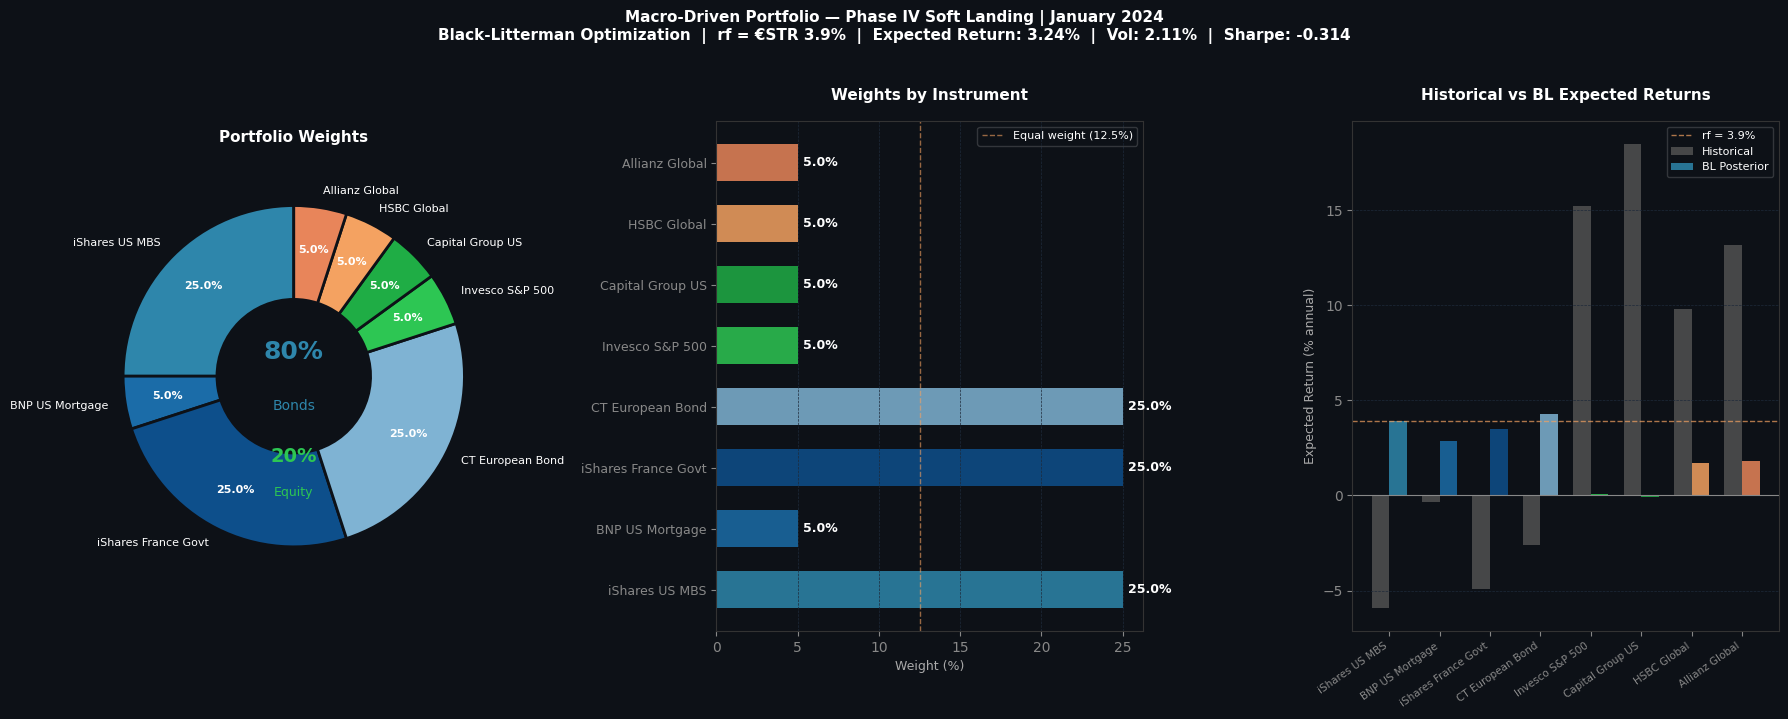

✅  Gráfico guardado → portfolio_final.png


In [25]:
fig, axes = plt.subplots(1, 3, figsize=(18, 7))
fig.patch.set_facecolor("#0D1117")
fig.suptitle(
    f"Macro-Driven Portfolio — Phase IV Soft Landing | January 2024\n"
    f"Black-Litterman Optimization  |  rf = €STR 3.9%  |  "
    f"Expected Return: {ret_opt:.2%}  |  Vol: {vol_opt:.2%}  |  Sharpe: {sharpe_opt:.3f}",
    fontsize=11, fontweight="bold", color="white", y=1.02
)

# ── Colores por rol ───────────────────────────────────────────────────────────
rol_colors = {
    "CORE"      : ["#2E86AB", "#1B6CA8", "#0D4F8B", "#7FB3D3"],
    "TRANSICION": ["#2DC653", "#1FAD45", "#F4A261", "#E8855A"],
}

nombres_cortos = [
    "iShares US MBS",
    "BNP US Mortgage",
    "iShares France Govt",
    "CT European Bond",
    "Invesco S&P 500",
    "Capital Group US",
    "HSBC Global",
    "Allianz Global",
]

roles = ["CORE","CORE","CORE","CORE",
         "TRANSICION","TRANSICION","TRANSICION","TRANSICION"]

colors = [rol_colors["CORE"][i]      if r == "CORE"
          else rol_colors["TRANSICION"][i-4]
          for i, r in enumerate(roles)]

# ── 1. Donut chart ────────────────────────────────────────────────────────────
ax1 = axes[0]
ax1.set_facecolor("#0D1117")

wedges, texts, autotexts = ax1.pie(
    w_opt,
    labels     = nombres_cortos,
    autopct    = "%1.1f%%",
    colors     = colors,
    startangle = 90,
    pctdistance= 0.75,
    wedgeprops = dict(width=0.55, edgecolor="#0D1117", linewidth=2),
)
for text in texts:
    text.set_color("white")
    text.set_fontsize(8)
for autotext in autotexts:
    autotext.set_color("white")
    autotext.set_fontsize(8)
    autotext.set_fontweight("bold")

# Texto central
ax1.text(0, 0.1,  "80%",   ha="center", fontsize=18,
         fontweight="bold", color="#2E86AB")
ax1.text(0, -0.2, "Bonds", ha="center", fontsize=10, color="#2E86AB")
ax1.text(0, -0.5, "20%",   ha="center", fontsize=14,
         fontweight="bold", color="#2DC653")
ax1.text(0, -0.7, "Equity",ha="center", fontsize=9,  color="#2DC653")

ax1.set_title("Portfolio Weights", fontsize=11,
              fontweight="bold", color="white", pad=15)

# ── 2. Barras horizontales ────────────────────────────────────────────────────
ax2 = axes[1]
ax2.set_facecolor("#0D1117")

y_pos = range(len(nombres_cortos))
bars  = ax2.barh(list(y_pos), w_opt * 100,
                 color=colors, alpha=0.85, height=0.6)

ax2.set_yticks(list(y_pos))
ax2.set_yticklabels(nombres_cortos, color="white", fontsize=9)
ax2.set_xlabel("Weight (%)", color="#AAAAAA", fontsize=9)
ax2.tick_params(colors="#888888")
ax2.set_facecolor("#0D1117")
ax2.grid(True, color="#1E2A3A", lw=0.5, ls="--", axis="x")
for spine in ax2.spines.values():
    spine.set_color("#333333")

# Etiquetas de valor
for bar, peso in zip(bars, w_opt):
    ax2.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
             f"{peso:.1%}", va="center", color="white", fontsize=9,
             fontweight="bold")

# Línea de equal weight
ax2.axvline(100/n, color="#F4A261", lw=1, ls="--", alpha=0.6,
            label=f"Equal weight ({100/n:.1f}%)")
ax2.legend(fontsize=8, framealpha=0.2, labelcolor="white",
           facecolor="#0D1117")
ax2.set_title("Weights by Instrument", fontsize=11,
              fontweight="bold", color="white", pad=15)

# ── 3. Retornos BL vs históricos ─────────────────────────────────────────────
ax3 = axes[2]
ax3.set_facecolor("#0D1117")

x      = np.arange(len(nombres_cortos))
width  = 0.35
hist_v = [mu_hist.iloc[i] * 100 for i in range(n)]
bl_v   = [mu_bl.iloc[0, i] * 100 for i in range(n)]

bars1 = ax3.bar(x - width/2, hist_v, width,
                label="Historical", color="#555555", alpha=0.8)
bars2 = ax3.bar(x + width/2, bl_v,   width,
                label="BL Posterior", color=colors, alpha=0.85)

ax3.axhline(0,   color="#888888", lw=0.8)
ax3.axhline(rf * 100, color="#F4A261", lw=1, ls="--",
            alpha=0.7, label=f"rf = {rf:.1%}")

ax3.set_xticks(x)
ax3.set_xticklabels(nombres_cortos, rotation=35, ha="right",
                    color="white", fontsize=7.5)
ax3.set_ylabel("Expected Return (% annual)", color="#AAAAAA", fontsize=9)
ax3.tick_params(colors="#888888")
ax3.grid(True, color="#1E2A3A", lw=0.5, ls="--", axis="y")
for spine in ax3.spines.values():
    spine.set_color("#333333")
ax3.legend(fontsize=8, framealpha=0.2, labelcolor="white",
           facecolor="#0D1117")
ax3.set_title("Historical vs BL Expected Returns",
              fontsize=11, fontweight="bold", color="white", pad=15)

plt.tight_layout()
plt.savefig("portfolio_final.png", dpi=150, bbox_inches="tight",
            facecolor=fig.get_facecolor())
plt.show()
print("✅  Gráfico guardado → portfolio_final.png")

## Backtest — Semiannual Macro Rebalancing (Jan 2024 → Jan 2026)

We simulate the strategy over 2 years with semiannual rebalancing. At each
rebalancing date, the macro cycle is re-evaluated automatically using live
FRED data. If the detected phase changes, views and portfolio weights are
updated accordingly via a new Black-Litterman optimization.

This mimics a realistic systematic wealth management process — macro-driven,
rules-based, and fully replicable.

In [26]:
# ── Descargar precios extendidos hasta Enero 2026 ─────────────────────────────
print("Descargando precios extendidos 2021 → 2026...")

precios_ext = {}
for isin, meta in CARTERA_ISINS.items():
    try:
        hist = yf.Ticker(isin).history(start="2021-01-01", end="2026-02-01")
        if len(hist) > 10:
            precios_ext[isin] = hist["Close"]
            print(f"  ✅  {meta['name'][:45]}")
        else:
            print(f"  ❌  {meta['name'][:45]} — sin datos")
    except Exception as e:
        print(f"  ❌  {meta['name'][:45]} — error: {e}")

# ── Construir DataFrame extendido ────────────────────────────────────────────
df_ext = pd.DataFrame(precios_ext)
df_ext.index = pd.to_datetime(df_ext.index).tz_localize(None)
df_ext = df_ext.resample("ME").last()
df_ext = df_ext["2021-01-01":"2026-01-31"].dropna(how="all")

# Renombrar
nombre_corto = {isin: meta["name"][:30] for isin, meta in CARTERA_ISINS.items()}
df_ext = df_ext.rename(columns=nombre_corto)

# Retornos completos
retornos_ext = df_ext.pct_change().dropna()

print(f"\nDataFrame extendido:")
print(f"  Período : {df_ext.index[0].strftime('%b %Y')} → "
      f"{df_ext.index[-1].strftime('%b %Y')}")
print(f"  Meses   : {len(df_ext)}")
print(f"  Activos : {len(df_ext.columns)}")

# Verificar outliers
print(f"\nVerificación outliers (>20% mensual):")
for col in retornos_ext.columns:
    out = retornos_ext[col][retornos_ext[col].abs() > 0.20]
    if len(out) > 0:
        print(f"  ⚠️  {col[:35]} → {len(out)} outliers: {out.values}")
    else:
        print(f"  ✅  {col[:35]}")

Descargando precios extendidos 2021 → 2026...
  ✅  iShares US Mortgage Backed Securities UCITS E
  ✅  BNP Paribas Flexi I US Mortgage I Capitalisat
  ✅  iShares France Govt Bond UCITS ETF EUR (Dist)
  ✅  CT European Bond Fund Institutional Gross Acc
  ✅  Invesco S&P 500 Scored & Screened ETF Acc
  ✅  Capital Group Investment Company of America (
  ✅  HSBC Multi Factor Worldwide Equity UCITS ETF 
  ✅  Allianz Best Styles Global AC Equity Fund C

DataFrame extendido:
  Período : Jan 2021 → Jan 2026
  Meses   : 61
  Activos : 8

Verificación outliers (>20% mensual):
  ✅  iShares US Mortgage Backed Sec
  ✅  BNP Paribas Flexi I US Mortgag
  ✅  iShares France Govt Bond UCITS
  ✅  CT European Bond Fund Institut
  ✅  Invesco S&P 500 Scored & Scree
  ✅  Capital Group Investment Compa
  ✅  HSBC Multi Factor Worldwide Eq
  ✅  Allianz Best Styles Global AC 


In [27]:
import riskfolio as rp
from scipy.optimize import minimize

# ── Función: fetch FRED ───────────────────────────────────────────────────────
FRED_BASE = "https://fred.stlouisfed.org/graph/fredgraph.csv?id="

def fetch_fred(series_id, transform="level"):
    """
    Descarga una serie de FRED y la devuelve como pd.Series mensual.
    transform:
        'level' → valores crudos
        'yoy'   → variación % anual (año contra año)
    """
    url = f"{FRED_BASE}{series_id}"
    df  = pd.read_csv(url, index_col=0, parse_dates=True, na_values=".")
    s   = df.iloc[:, 0].dropna()
    s   = s.resample("ME").last().dropna()
    if transform == "yoy":
        s = s.pct_change(12) * 100
    return s

# ── Función: evaluar macro ────────────────────────────────────────────────────
def evaluar_macro(fecha_corte):
    indpro = fetch_fred("INDPRO",    transform="yoy")[:fecha_corte]
    yc     = fetch_fred("T10Y2Y",    transform="level")[:fecha_corte]
    cpi    = fetch_fred("CPIAUCSL",  transform="yoy")[:fecha_corte]
    ppi    = fetch_fred("PPIACO",    transform="yoy")[:fecha_corte]

    def tend(s): return s.iloc[-1] - s.iloc[-4] if len(s) >= 4 else 0

    def score(nivel, umbral, tendencia):
        s_nivel = 1 if nivel > umbral else -1
        s_tend  = 1 if tendencia > 0  else -1
        return 0.40 * s_nivel + 0.60 * s_tend

    indpro_yoy  = indpro.iloc[-1]
    indpro_tend = tend(indpro)
    indpro_mom  = indpro.diff(3).iloc[-1]
    yc_val      = yc.iloc[-1]
    yc_tend     = tend(yc)

    s_indpro_nivel = score(indpro_yoy, 0, indpro_tend)
    s_indpro_mom   = 1 if indpro_mom > 0 else -1
    s_yc           = score(yc_val,     0, yc_tend)

    growth = (0.45 * s_indpro_nivel +
              0.35 * s_indpro_mom   +
              0.20 * s_yc)

    cpi_val   = cpi.iloc[-1]
    cpi_tend  = tend(cpi)
    ppi_val   = ppi.iloc[-1]
    ppi_tend  = tend(ppi)
    cpi_mom   = cpi.diff(3).iloc[-1]
    cpi_mom_s = 1 if cpi_mom > 0 else -1

    s_cpi = score(cpi_val, 2, cpi_tend)
    s_ppi = score(ppi_val, 0, ppi_tend)

    inflation = (0.50 * s_cpi     +
                 0.30 * s_ppi     +
                 0.20 * cpi_mom_s)

    if   growth >= 0 and inflation <= 0: phase = "I"
    elif growth >= 0 and inflation >  0: phase = "II"
    elif growth <  0 and inflation >= 0: phase = "III"
    else:                                phase = "IV"

    distancia  = np.sqrt(growth**2 + inflation**2) / np.sqrt(2)
    conviccion = "ALTA"  if distancia >= 0.55 else \
                 "MEDIA" if distancia >= 0.30 else "BAJA"

    return {
        "phase"     : phase,
        "growth"    : round(growth,    3),
        "inflation" : round(inflation, 3),
        "conviccion": conviccion,
        "indpro_yoy": round(indpro_yoy, 2),
        "yc"        : round(yc_val,     2),
        "cpi"       : round(cpi_val,    2),
        "ppi"       : round(ppi_val,    2),
    }

# ── Función: views por fase ───────────────────────────────────────────────────
def get_views(phase, idx_bonds, idx_equity, idx_usd_bond,
              idx_eur_bond, idx_us_eq, idx_gl_eq, n):
    P = np.zeros((3, n))
    if phase in ("I", "II"):
        for i in idx_equity: P[0, i] = +1 / len(idx_equity)
        for i in idx_bonds:  P[0, i] = -1 / len(idx_bonds)
        for i in idx_us_eq:  P[1, i] = +1 / len(idx_us_eq)
        for i in idx_gl_eq:  P[1, i] = -1 / len(idx_gl_eq)
        for i in idx_equity: P[2, i] = +1 / len(idx_equity)
        for i in idx_bonds:  P[2, i] = -1 / len(idx_bonds)
        Q = np.array([0.06, 0.02, 0.05])
    elif phase == "III":
        for i in idx_bonds:    P[0, i] = +1 / len(idx_bonds)
        for i in idx_equity:   P[0, i] = -1 / len(idx_equity)
        for i in idx_usd_bond: P[1, i] = +1 / len(idx_usd_bond)
        for i in idx_eur_bond: P[1, i] = -1 / len(idx_eur_bond)
        for i in idx_bonds:    P[2, i] = +1 / len(idx_bonds)
        for i in idx_equity:   P[2, i] = -1 / len(idx_equity)
        Q = np.array([0.07, 0.02, 0.06])
    else:  # Phase IV
        for i in idx_usd_bond: P[0, i] = +1 / len(idx_usd_bond)
        for i in idx_us_eq:    P[0, i] = -1 / len(idx_us_eq)
        for i in idx_eur_bond: P[1, i] = +1 / len(idx_eur_bond)
        for i in idx_gl_eq:    P[1, i] = -1 / len(idx_gl_eq)
        for i in idx_bonds:    P[2, i] = +1 / len(idx_bonds)
        for i in idx_equity:   P[2, i] = -1 / len(idx_equity)
        Q = np.array([0.05, 0.03, 0.04])
    return P, Q

# ── Función: optimizar pesos ──────────────────────────────────────────────────
def optimizar_pesos_periodo(ret_hist, phase, rf=0.039, delta=2.5):
    n      = len(ret_hist.columns)
    assets = list(ret_hist.columns)

    idx_usd_bond = [i for i, a in enumerate(assets) if any(
        x in a for x in ["Mortgage Backed", "BNP Paribas"])]
    idx_eur_bond = [i for i, a in enumerate(assets) if any(
        x in a for x in ["France Govt", "CT European"])]
    idx_us_eq    = [i for i, a in enumerate(assets) if any(
        x in a for x in ["Invesco S&P", "Capital Group"])]
    idx_gl_eq    = [i for i, a in enumerate(assets) if any(
        x in a for x in ["HSBC Multi", "Allianz"])]
    idx_bonds    = idx_usd_bond + idx_eur_bond
    idx_equity   = idx_us_eq + idx_gl_eq

    P, Q = get_views(phase, idx_bonds, idx_equity,
                     idx_usd_bond, idx_eur_bond,
                     idx_us_eq, idx_gl_eq, n)

    P_df    = pd.DataFrame(P, columns=ret_hist.columns)
    Q_df    = pd.DataFrame(Q.reshape(-1, 1))
    w_prior = pd.DataFrame([1/n]*n,
                           index=ret_hist.columns,
                           columns=["weights"])

    port = rp.Portfolio(returns=ret_hist)
    port.assets_stats(method_mu="hist", method_cov="hist")

    mu_bl, cov_bl, _ = rp.black_litterman(
        X=ret_hist, w=w_prior, P=P_df, Q=Q_df,
        delta=delta, rf=rf, eq=True,
    )

    mu_vec  = mu_bl.values.flatten()
    cov_mat = cov_bl.values

    def neg_sharpe(w):
        ret = mu_vec @ w
        vol = np.sqrt(w @ cov_mat @ w)
        return -(ret - rf) / vol if vol > 0 else 0

    if phase in ("I", "II"):
        constraints = [
            {"type": "eq",   "fun": lambda w: np.sum(w) - 1},
            {"type": "ineq", "fun": lambda w: sum(w[i] for i in idx_equity) - 0.40},
            {"type": "ineq", "fun": lambda w: 0.60 - sum(w[i] for i in idx_bonds)},
        ]
    else:
        constraints = [
            {"type": "eq",   "fun": lambda w: np.sum(w) - 1},
            {"type": "ineq", "fun": lambda w: sum(w[i] for i in idx_bonds)  - 0.40},
            {"type": "ineq", "fun": lambda w: 0.60 - sum(w[i] for i in idx_equity)},
        ]

    bounds = [(0.05, 0.25)] * n
    result = minimize(neg_sharpe, [1/n]*n, method="SLSQP",
                      bounds=bounds, constraints=constraints,
                      options={"maxiter": 1000, "ftol": 1e-9})

    return result.x if result.success else np.array([1/n]*n)

# ── BACKTEST PRINCIPAL ────────────────────────────────────────────────────────
REBALANCEO_FECHAS = [
    "2024-01-31",
    "2024-07-31",
    "2025-01-31",
    "2025-07-31",
]
FECHA_FIN = "2026-01-31"

PHASE_LABELS = {
    "I"  : "Recovery",
    "II" : "Overheating",
    "III": "Hard Landing",
    "IV" : "Soft Landing",
}

PHASE_COLORS = {
    "I"  : "#2DC653",
    "II" : "#F4A261",
    "III": "#E63946",
    "IV" : "#2E86AB",
}

print("BACKTEST — Macro-Driven Portfolio")
print("Período: Enero 2024 → Enero 2026 | Rebalanceo Semestral")
print("=" * 65)

historial = []
valor     = 100.0

for idx_fecha, fecha_inicio in enumerate(REBALANCEO_FECHAS):

    fecha_fin = REBALANCEO_FECHAS[idx_fecha + 1] \
                if idx_fecha + 1 < len(REBALANCEO_FECHAS) \
                else FECHA_FIN

    print(f"\n{'─'*65}")
    print(f"  PERÍODO {idx_fecha+1}: {fecha_inicio[:7]} → {fecha_fin[:7]}")

    macro = evaluar_macro(fecha_inicio)
    phase = macro["phase"]
    print(f"  Phase {phase} — {PHASE_LABELS[phase]}  |  "
          f"Growth: {macro['growth']:+.2f}  |  "
          f"Inflation: {macro['inflation']:+.2f}  |  "
          f"Convicción: {macro['conviccion']}")

    ret_hist = retornos_ext[retornos_ext.index <= fecha_inicio].copy()
    pesos    = optimizar_pesos_periodo(ret_hist, phase)

    assets = list(retornos_ext.columns)
    print(f"  Pesos: ", end="")
    for i, nombre in enumerate(assets):
        print(f"{nombre[:15]}: {pesos[i]:.0%}", end="  ")
    print()

    mask        = (retornos_ext.index > pd.to_datetime(fecha_inicio)) & \
                  (retornos_ext.index <= pd.to_datetime(fecha_fin))
    ret_periodo = retornos_ext[mask].copy()

    if ret_periodo.empty:
        print(f"  ⚠️  Sin datos para este período")
        continue

    ret_cartera = ret_periodo @ pesos
    ret_acum    = (1 + ret_cartera).prod() - 1
    vol_periodo = ret_cartera.std() * np.sqrt(12)
    sharpe_p    = (ret_acum - 0.039/2) / vol_periodo if vol_periodo > 0 else 0

    valor_ant = valor
    valor     = valor * (1 + ret_acum)

    print(f"  Retorno período : {ret_acum:+.2%}  |  "
          f"Vol: {vol_periodo:.2%}  |  "
          f"Sharpe: {sharpe_p:.3f}")
    print(f"  Valor cartera   : {valor_ant:.2f} → {valor:.2f}")

    historial.append({
        "periodo"    : f"{fecha_inicio[:7]}→{fecha_fin[:7]}",
        "phase"      : phase,
        "label"      : PHASE_LABELS[phase],
        "pesos"      : pesos.copy(),
        "ret_acum"   : ret_acum,
        "volatilidad": vol_periodo,
        "sharpe"     : sharpe_p,
        "valor_ini"  : valor_ant,
        "valor_fin"  : valor,
        "ret_mensual": ret_cartera,
    })

# ── Resumen ───────────────────────────────────────────────────────────────────
print(f"\n{'='*65}")
print(f"  RESUMEN BACKTEST")
print(f"{'='*65}")
print(f"  Valor inicial  : 100.00")
print(f"  Valor final    : {valor:.2f}")
print(f"  Retorno total  : {(valor/100 - 1):+.2%}")

if historial:
    ret_anual  = (valor/100) ** (1/2) - 1
    todos_ret  = pd.concat([h["ret_mensual"] for h in historial])
    vol_total  = todos_ret.std() * np.sqrt(12)
    sharpe_tot = (ret_anual - 0.039) / vol_total if vol_total > 0 else 0
    nav        = (1 + todos_ret).cumprod() * 100
    max_dd     = (nav / nav.cummax() - 1).min()

    print(f"  Retorno anual  : {ret_anual:+.2%}")
    print(f"  Volatilidad    : {vol_total:.2%}")
    print(f"  Sharpe total   : {sharpe_tot:.3f}")
    print(f"  Max Drawdown   : {max_dd:.2%}")
    print(f"\n  Fases por período:")
    for h in historial:
        print(f"    {h['periodo']}  Phase {h['phase']} "
              f"{h['label']:<15}  ret: {h['ret_acum']:>+.2%}  "
              f"valor: {h['valor_fin']:.2f}")

BACKTEST — Macro-Driven Portfolio
Período: Enero 2024 → Enero 2026 | Rebalanceo Semestral

─────────────────────────────────────────────────────────────────
  PERÍODO 1: 2024-01 → 2024-07
  Phase IV — Soft Landing  |  Growth: -1.00  |  Inflation: -0.24  |  Convicción: ALTA
  Pesos: iShares US Mort: 25%  BNP Paribas Fle: 5%  iShares France : 25%  CT European Bon: 25%  Invesco S&P 500: 5%  Capital Group I: 5%  HSBC Multi Fact: 5%  Allianz Best St: 5%  
  Retorno período : +3.51%  |  Vol: 5.34%  |  Sharpe: 0.292
  Valor cartera   : 100.00 → 103.51

─────────────────────────────────────────────────────────────────
  PERÍODO 2: 2024-07 → 2025-01
  Phase I — Recovery  |  Growth: +0.48  |  Inflation: +0.00  |  Convicción: MEDIA
  Pesos: iShares US Mort: 5%  BNP Paribas Fle: 5%  iShares France : 5%  CT European Bon: 5%  Invesco S&P 500: 25%  Capital Group I: 5%  HSBC Multi Fact: 25%  Allianz Best St: 25%  
  Retorno período : +8.42%  |  Vol: 6.83%  |  Sharpe: 0.948
  Valor cartera   : 103.51 →

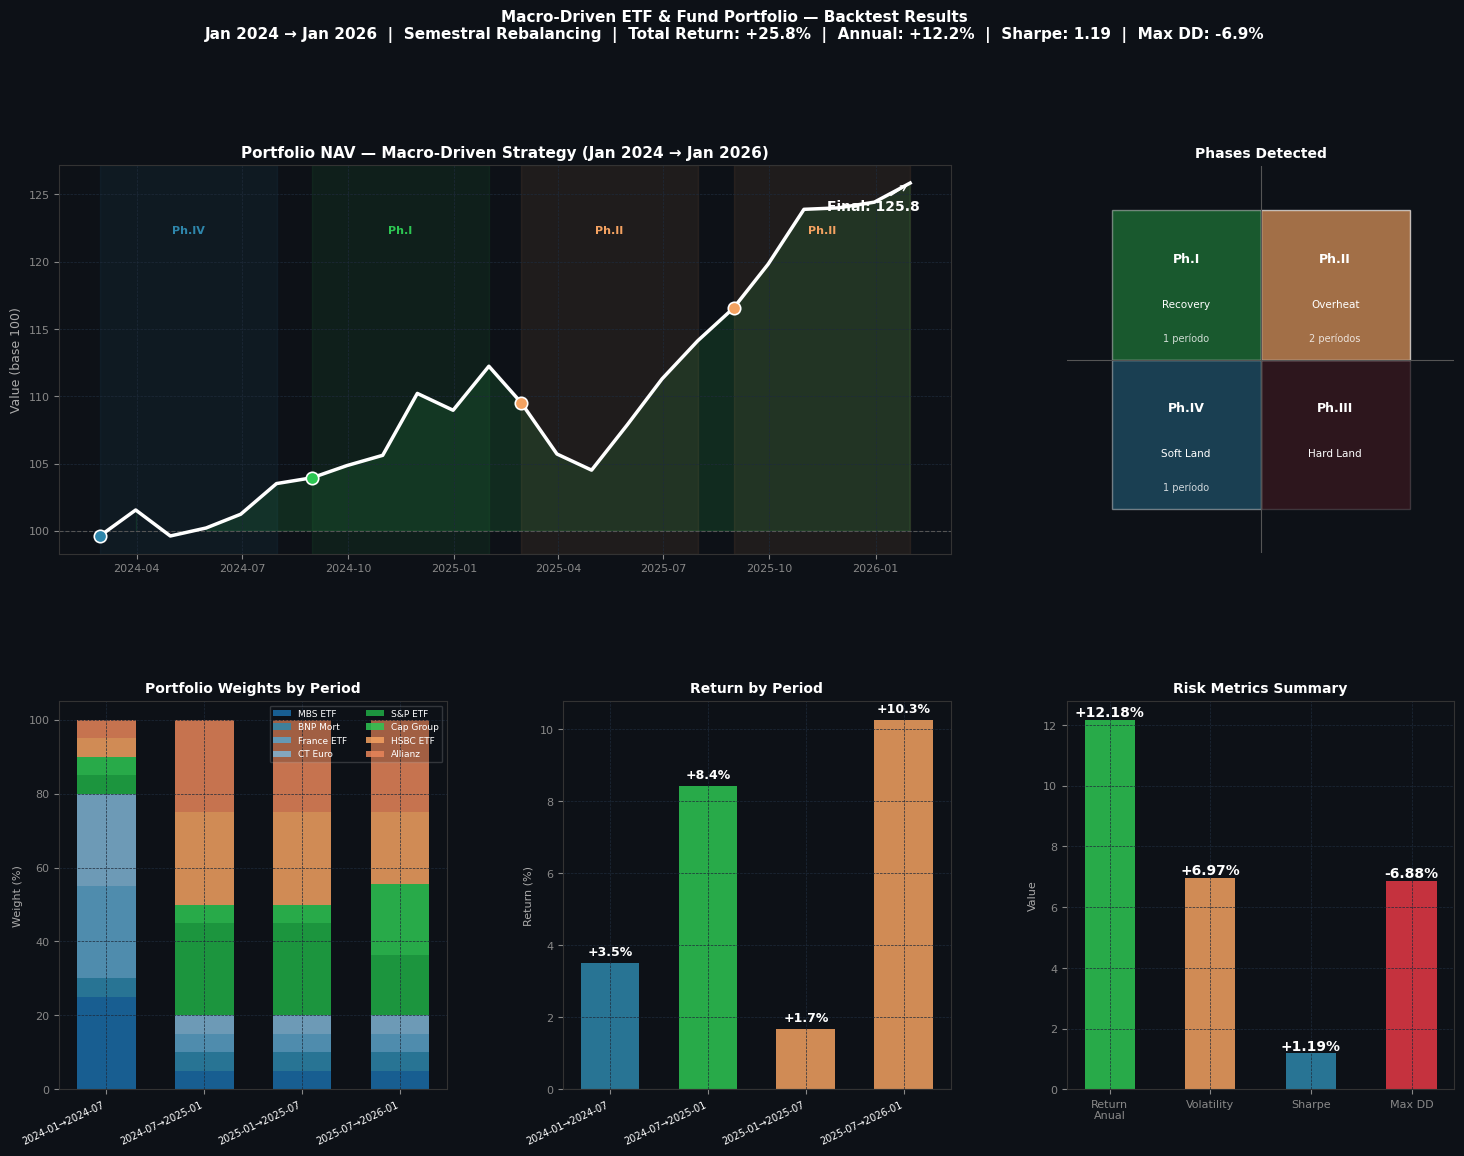

✅  Gráfico guardado → backtest_results.png


In [28]:
import matplotlib.gridspec as gridspec
import matplotlib.ticker as mticker

fig = plt.figure(figsize=(18, 12))
fig.patch.set_facecolor("#0D1117")

gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.38, wspace=0.30)

ax_nav    = fig.add_subplot(gs[0, :2])
ax_clock  = fig.add_subplot(gs[0, 2])
ax_pesos  = fig.add_subplot(gs[1, 0])
ax_ret    = fig.add_subplot(gs[1, 1])
ax_risk   = fig.add_subplot(gs[1, 2])

for ax in [ax_nav, ax_clock, ax_pesos, ax_ret, ax_risk]:
    ax.set_facecolor("#0D1117")
    for spine in ax.spines.values():
        spine.set_color("#333333")
    ax.tick_params(colors="#888888", labelsize=8)
    ax.grid(True, color="#1E2A3A", lw=0.5, ls="--")

PHASE_COLORS = {
    "I"  : "#2DC653",
    "II" : "#F4A261",
    "III": "#E63946",
    "IV" : "#2E86AB",
}

# ── 1. NAV ────────────────────────────────────────────────────────────────────
todos_ret = pd.concat([h["ret_mensual"] for h in historial])
nav       = (1 + todos_ret).cumprod() * 100
nav.index = pd.to_datetime(nav.index)

ax_nav.plot(nav.index, nav.values, color="white", lw=2.5, zorder=5)
ax_nav.fill_between(nav.index, 100, nav.values,
                    where=nav.values >= 100, alpha=0.15, color="#2DC653")
ax_nav.fill_between(nav.index, 100, nav.values,
                    where=nav.values < 100,  alpha=0.15, color="#E63946")
ax_nav.axhline(100, color="#555555", lw=0.8, ls="--")

fechas_inicio = [pd.to_datetime(h["ret_mensual"].index[0])  for h in historial]
fechas_fin    = [pd.to_datetime(h["ret_mensual"].index[-1]) for h in historial]

for h, fi, ff in zip(historial, fechas_inicio, fechas_fin):
    ax_nav.axvspan(fi, ff, alpha=0.08, color=PHASE_COLORS[h["phase"]])
    mid = fi + (ff - fi) / 2
    ax_nav.text(mid, nav.max() * 0.97, f"Ph.{h['phase']}",
                ha="center", fontsize=8,
                color=PHASE_COLORS[h["phase"]], fontweight="bold")

for h in historial:
    fecha_rb = pd.to_datetime(h["ret_mensual"].index[0])
    val_rb   = nav[nav.index >= fecha_rb].iloc[0]
    ax_nav.scatter(fecha_rb, val_rb, color=PHASE_COLORS[h["phase"]],
                   s=80, zorder=10, edgecolors="white", lw=1.2)

ax_nav.set_title("Portfolio NAV — Macro-Driven Strategy (Jan 2024 → Jan 2026)",
                 fontsize=11, fontweight="bold", color="white")
ax_nav.set_ylabel("Value (base 100)", color="#AAAAAA", fontsize=9)
ax_nav.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.0f"))
ax_nav.annotate(f"Final: {nav.iloc[-1]:.1f}",
                xy=(nav.index[-1], nav.iloc[-1]),
                xytext=(-60, -20), textcoords="offset points",
                color="white", fontsize=10, fontweight="bold",
                arrowprops=dict(arrowstyle="->", color="white", lw=1))

# ── 2. Clock ──────────────────────────────────────────────────────────────────
ax_clock.set_xlim(-1.3, 1.3)
ax_clock.set_ylim(-1.3, 1.3)
ax_clock.set_aspect("equal")
ax_clock.axis("off")

quad = [("I", -1, 0, "Recovery"), ("II", 0, 0, "Overheat"),
        ("III", 0, -1, "Hard Land"), ("IV", -1, -1, "Soft Land")]

for ph, x0, y0, lbl in quad:
    count = sum(1 for h in historial if h["phase"] == ph)
    alpha = 0.15 + 0.25 * count
    rect  = plt.Rectangle((x0, y0), 1, 1,
                           facecolor=PHASE_COLORS[ph],
                           alpha=min(alpha, 0.85),
                           edgecolor="white", linewidth=1)
    ax_clock.add_patch(rect)
    ax_clock.text(x0+0.5, y0+0.65, f"Ph.{ph}",
                  ha="center", fontsize=9, fontweight="bold", color="white")
    ax_clock.text(x0+0.5, y0+0.35, lbl,
                  ha="center", fontsize=7.5, color="white")
    if count > 0:
        ax_clock.text(x0+0.5, y0+0.12,
                      f"{count} período{'s' if count>1 else ''}",
                      ha="center", fontsize=7, color="white", alpha=0.8)

ax_clock.axhline(0, color="#555555", lw=0.8)
ax_clock.axvline(0, color="#555555", lw=0.8)
ax_clock.set_title("Phases Detected", fontsize=10,
                   fontweight="bold", color="white")

# ── 3. Pesos por período ──────────────────────────────────────────────────────
nombres_cortos = ["MBS ETF", "BNP Mort", "France ETF", "CT Euro",
                  "S&P ETF", "Cap Group", "HSBC ETF", "Allianz"]
periodos   = [h["periodo"] for h in historial]
pesos_mat  = np.array([h["pesos"] for h in historial])
col_act    = ["#1B6CA8","#2E86AB","#5BA3C9","#7FB3D3",
              "#1FAD45","#2DC653","#F4A261","#E8855A"]

bottom = np.zeros(len(historial))
for i, (nombre, color) in enumerate(zip(nombres_cortos, col_act)):
    ax_pesos.bar(periodos, pesos_mat[:, i] * 100,
                 bottom=bottom * 100,
                 label=nombre, color=color, alpha=0.85, width=0.6)
    bottom += pesos_mat[:, i]

ax_pesos.set_title("Portfolio Weights by Period",
                   fontsize=10, fontweight="bold", color="white")
ax_pesos.set_ylabel("Weight (%)", color="#AAAAAA", fontsize=8)
ax_pesos.set_xticklabels(periodos, rotation=25, ha="right",
                         color="white", fontsize=7)
ax_pesos.legend(fontsize=6.5, framealpha=0.2, labelcolor="white",
                facecolor="#0D1117", ncol=2, loc="upper right")
ax_pesos.set_ylim(0, 105)

# ── 4. Retorno por período ────────────────────────────────────────────────────
retornos_p = [h["ret_acum"] * 100 for h in historial]
colores_p  = [PHASE_COLORS[h["phase"]] for h in historial]

bars = ax_ret.bar(periodos, retornos_p, color=colores_p, alpha=0.85, width=0.6)
ax_ret.axhline(0, color="#555555", lw=0.8)
for bar, ret in zip(bars, retornos_p):
    ax_ret.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.2,
                f"{ret:+.1f}%",
                ha="center", fontsize=9, fontweight="bold", color="white")

ax_ret.set_title("Return by Period", fontsize=10,
                 fontweight="bold", color="white")
ax_ret.set_ylabel("Return (%)", color="#AAAAAA", fontsize=8)
ax_ret.set_xticklabels(periodos, rotation=25, ha="right",
                       color="white", fontsize=7)

# ── 5. Métricas de riesgo ─────────────────────────────────────────────────────
ret_anual = (nav.iloc[-1]/100) ** (1/2) - 1
vol_total = todos_ret.std() * np.sqrt(12)
sharpe_t  = (ret_anual - 0.039) / vol_total
mdd       = (nav / nav.cummax() - 1).min()

metricas  = ["Return\nAnual", "Volatility", "Sharpe", "Max DD"]
valores   = [ret_anual*100, vol_total*100, sharpe_t, mdd*100]
colores_m = ["#2DC653", "#F4A261", "#2E86AB", "#E63946"]

bars2 = ax_risk.bar(metricas, [abs(v) for v in valores],
                    color=colores_m, alpha=0.85, width=0.5)
for bar, val in zip(bars2, valores):
    ax_risk.text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.1,
                 f"{val:+.2f}{'%' if abs(val) > 1 else ''}",
                 ha="center", fontsize=10,
                 fontweight="bold", color="white")

ax_risk.set_title("Risk Metrics Summary", fontsize=10,
                  fontweight="bold", color="white")
ax_risk.set_ylabel("Value", color="#AAAAAA", fontsize=8)

# ── Título general ────────────────────────────────────────────────────────────
fig.suptitle(
    f"Macro-Driven ETF & Fund Portfolio — Backtest Results\n"
    f"Jan 2024 → Jan 2026  |  Semestral Rebalancing  |  "
    f"Total Return: +{(nav.iloc[-1]-100):.1f}%  |  "
    f"Annual: +{ret_anual:.1%}  |  Sharpe: {sharpe_t:.2f}  |  "
    f"Max DD: {mdd:.1%}",
    fontsize=11, fontweight="bold", color="white", y=1.01
)

plt.savefig("backtest_results.png", dpi=150, bbox_inches="tight",
            facecolor=fig.get_facecolor())
plt.show()
print("✅  Gráfico guardado → backtest_results.png")